---
# 05. 텍스트 분석

## 분석 개요

Convenience QSR 업종에서 FPI 구간별 언어 패턴과
생존/고전 브랜드의 차별화 요인을 다각도로 분석한다.

팀플의 TF-IDF 차이 방식에서 한 단계 나아가
N-gram, Sentiment Intensity, Topic Modeling을 추가하여
리뷰 텍스트의 맥락과 주제 구조까지 탐색한다.

**TF-IDF 차이 방식의 한계**

TF-IDF 차이는 단어 빈도 기반이라 "어떤 단어가 많이 나오는가" 만 확인한다. 문맥, 감정 강도, 단어 조합을 전혀 못 본다. 그래서 buffet, line, wait 같은 단어가 나와도 긍정적 맥락인지 부정적 맥락인지 구분이 안되는 한계를 가짐.

| 단계 | 방법 | 목적 |
|---|---|---|
| STEP 5-1 | 데이터 준비 | 리뷰 + FPI 구간 태깅 |
| STEP 5-2 | TF-IDF 차이 | FPI 구간별 고유 키워드 (팀플 방식, 비교 기준) |
| STEP 5-3 | 생존/고전 브랜드 정의 | HP 구간 그룹 분류 |
| STEP 5-4 | TF-IDF 차이 | 생존 vs 고전 키워드 비교 |
| STEP 5-5 | N-gram 분석 | 생존 vs 고전 구(phrase) 단위 비교 |
| STEP 5-6 | Sentiment Intensity | 생존 vs 고전 감정 강도 비교 |
| STEP 5-7 | Topic Modeling (LDA) | 생존 vs 고전 주제 구조 비교 |
| STEP 5-8 | 생존 브랜드 vs 프랜차이즈 | 차별화 키워드 비교 |

**분석 방법론 비교**

| 방법 | 무엇을 보는가 | 한계 |
|---|---|---|
| TF-IDF 차이 | 단어 빈도 차이 | 문맥, 감정 강도 무시 |
| N-gram | 구(phrase) 단위 표현 | 빈도 기반, 의미 파악 제한 |
| Sentiment Intensity | 감정 강도 분포 | 도메인 특화 어휘 약점 |
| LDA Topic Modeling | 잠재 주제 구조 | 토픽 수 설정 주관적 |

**그룹 정의**
- 생존 브랜드: HP + is_open=1 + 별점 4.0↑ + 리뷰수 10개↑
- 고전 브랜드: HP + is_open=1 + 별점 3.0↓ + 리뷰수 10개↑

**입력 데이터**
- `biz_indie_with_groups_qsr.csv`
- `review_qsr_cleaned.csv`
- `review_target_qsr.csv` (프랜차이즈 비교용)
- `biz_target_qsr.csv` (프랜차이즈 비교용)

## 공통 라이브러리 및 설정

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import mannwhitneyu
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

nltk.download('stopwords', quiet=True)

PATH_to_data = "../results"
PATH_to_save = "../results"

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## STEP 5-1. 데이터 준비

In [ ]:
# 데이터 로드
indie_groups   = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups_qsr.csv")
review_cleaned = pd.read_csv(f"{PATH_to_data}/review_qsr_cleaned.csv")
review_cleaned['text_clean'] = review_cleaned['text_clean'].fillna('')

# 리뷰에 FPI 구간 + 별점 태깅
review_indie = review_cleaned.merge(
    indie_groups[['business_id', 'fpi_group', 'fpi_300m', 'stars', 'review_count']],
    on='business_id', how='inner'
)

print(f"독립 브랜드: {len(indie_groups):,}개")
print(f"리뷰 수: {len(review_indie):,}개")
print(f"\nFPI 구간별 리뷰 수:")
print(review_indie['fpi_group'].value_counts())

독립 브랜드: 775개
리뷰 수: 142,507개

FPI 구간별 리뷰 수:
fpi_group
HP    67829
LP    53581
NP    21097
Name: count, dtype: int64


---
## STEP 5-2. FPI 구간별 고유 키워드 (TF-IDF 차이)

팀플과 동일한 방식으로 구간별 고유 키워드를 추출한다.
이후 분석(N-gram, Sentiment, LDA)과의 비교 기준으로 활용한다.

**유효 단어 필터**: 전체 리뷰 500회↑ + 순수 알파벳 + 3글자↑

In [7]:
# 유효 단어 필터
all_text = ' '.join(review_indie['text_clean'].dropna()).split()
word_freq = pd.Series(all_text).value_counts()

MIN_COUNT = 500
valid_words = set(
    w for w, c in word_freq.items()
    if c >= MIN_COUNT and w.isalpha() and len(w) >= 3
)

print(f"전체 단어 수: {len(word_freq):,}개")
print(f"유효 단어 수: {len(valid_words):,}개")

# 구간별 텍스트 합치기
group_texts = {}
for group in ['NP', 'LP', 'HP']:
    texts = review_indie[review_indie['fpi_group'] == group]['text_clean']
    group_texts[group] = ' '.join(texts.dropna().tolist())
    print(f"{group}: {len(texts):,}개 리뷰")

# TF-IDF 계산
vectorizer = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_matrix = vectorizer.fit_transform(
    [group_texts['NP'], group_texts['LP'], group_texts['HP']]
)
terms = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=['NP', 'LP', 'HP'],
    columns=terms
)

# TF-IDF 차이 계산
tfidf_diff_results = {}
for group, others in [('NP', ['LP', 'HP']),
                       ('LP', ['NP', 'HP']),
                       ('HP', ['NP', 'LP'])]:
    diff = (tfidf_df.loc[group] - tfidf_df.loc[others].mean())\
           .sort_values(ascending=False)
    diff = diff[diff.index.isin(valid_words)]
    tfidf_diff_results[group] = diff

print("\n=== FPI 구간별 고유 키워드 ===")
for group in ['NP', 'LP', 'HP']:
    print(f"\n[{group}] 상위 15개:")
    print(tfidf_diff_results[group].head(15).round(4).to_string())

전체 단어 수: 88,018개
유효 단어 수: 1,642개
NP: 21,097개 리뷰
LP: 53,581개 리뷰
HP: 67,829개 리뷰

=== FPI 구간별 고유 키워드 ===

[NP] 상위 15개:
pizza       0.0757
sandwich    0.0671
coffe       0.0488
cafe        0.0352
owner       0.0281
truck       0.0279
love        0.0257
friendli    0.0229
salad       0.0212
custom      0.0191
slider      0.0188
vegan       0.0177
work        0.0176
fresh       0.0176
great       0.0175

[LP] 상위 15개:
burger       0.0387
great        0.0339
servic       0.0309
egg          0.0238
server       0.0208
potato       0.0191
beef         0.0172
bbq          0.0172
breakfast    0.0170
steak        0.0158
side         0.0155
menu         0.0146
pancak       0.0141
downtown     0.0138
beer         0.0138

[HP] 상위 15개:
buffet     0.1154
burger     0.1042
line       0.0640
wait       0.0390
vega       0.0369
crab       0.0335
dessert    0.0289
fri        0.0256
station    0.0234
truffl     0.0227
leg        0.0225
seafood    0.0209
bacchan    0.0207
long       0.0202
earl       0.0199


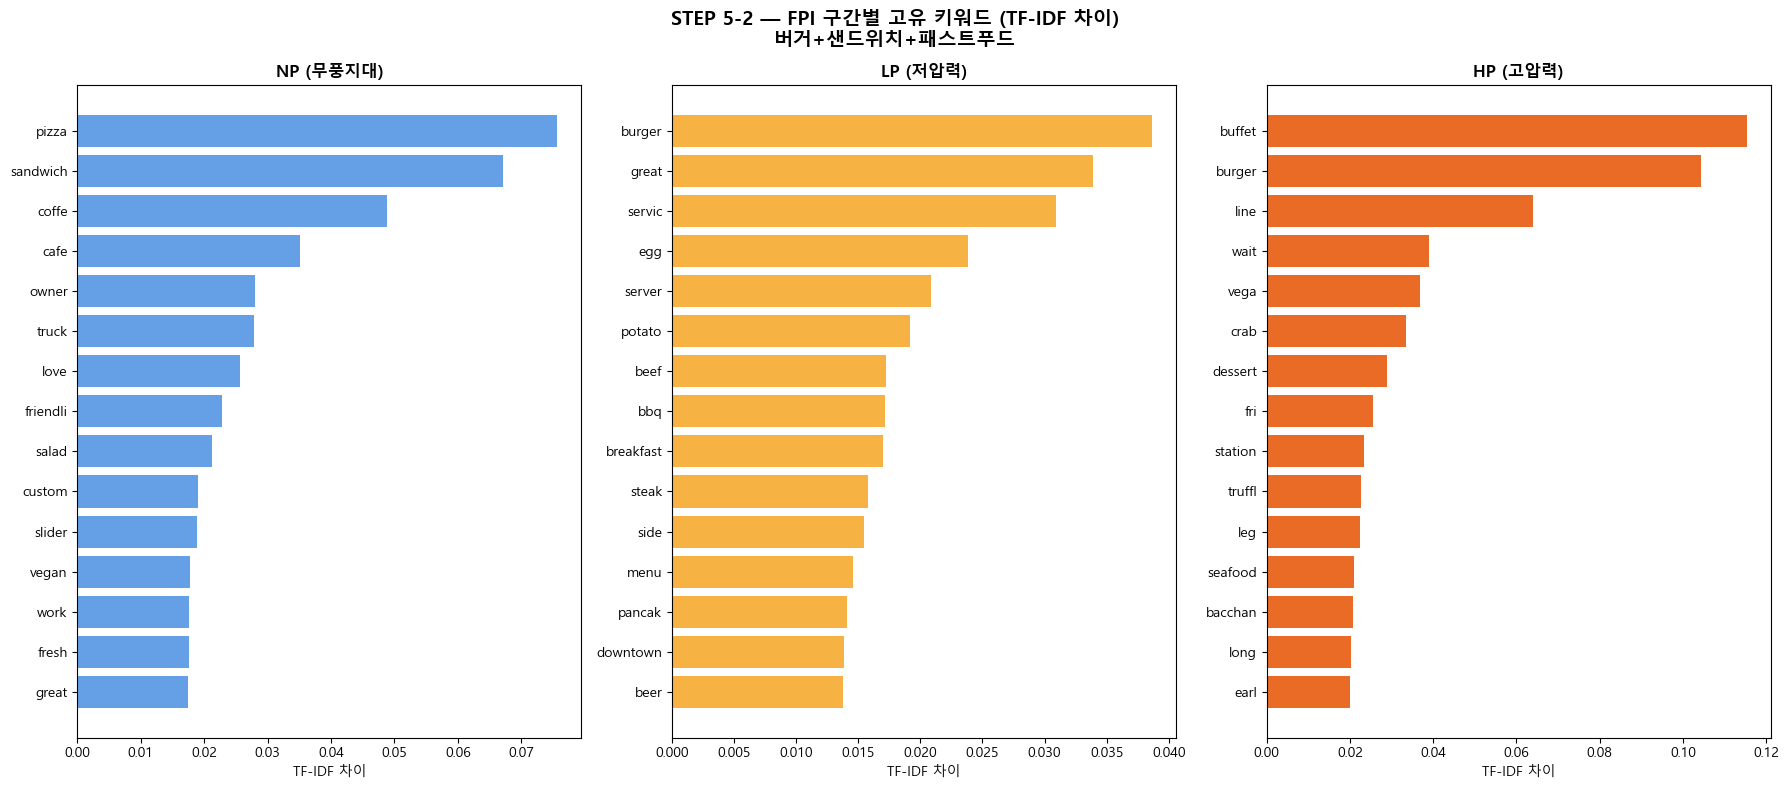

In [8]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
fig.suptitle('STEP 5-2 — FPI 구간별 고유 키워드 (TF-IDF 차이)\n버거+샌드위치+패스트푸드',
             fontsize=14, fontweight='bold')

bar_colors = {'NP': '#4a90e2', 'LP': '#f5a623', 'HP': '#e65100'}
titles = {'NP': 'NP (무풍지대)', 'LP': 'LP (저압력)', 'HP': 'HP (고압력)'}

for ax, group in zip(axes, ['NP', 'LP', 'HP']):
    top = tfidf_diff_results[group].head(15)
    ax.barh(top.index[::-1], top.values[::-1],
            color=bar_colors[group], alpha=0.85)
    ax.set_title(titles[group], fontsize=12, fontweight='bold')
    ax.set_xlabel('TF-IDF 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_fpi_keywords.png",
            dpi=150, bbox_inches='tight')
plt.show()

### STEP 5-2 결과 요약 — FPI 구간별 고유 키워드

| 구간 | 고유 키워드 | 해석 |
|---|---|---|
| NP (무풍지대) | pizza, sandwich, coffee, truck, vegan, fresh | 로컬 특색 업종, 푸드트럭, 소규모 독립 |
| LP (저압력) | burger, egg, potato, bbq, breakfast, steak | 정통 음식 전문성 중심 |
| HP (고압력) | buffet, burger, line, wait, crab, bacchanal | 뷔페 + 대기 + 카지노 상권 노이즈 |

팀플과 동일하게 HP 구간에서 카지노 뷔페 상권 노이즈가 확인되었다.

---
## STEP 5-3. 생존/고전 브랜드 정의

In [9]:
MIN_REVIEW = 10

hp_biz = indie_groups[
    (indie_groups['fpi_group'] == 'HP') &
    (indie_groups['is_open'] == 1)
].copy()

survivor = hp_biz[
    (hp_biz['stars'] >= 4.0) &
    (hp_biz['review_count'] >= MIN_REVIEW)
].copy()
struggle = hp_biz[
    (hp_biz['stars'] <= 3.0) &
    (hp_biz['review_count'] >= MIN_REVIEW)
].copy()

survivor['survival_group'] = '생존'
struggle['survival_group'] = '고전'
hp_labeled = pd.concat([survivor, struggle], ignore_index=True)

# 리뷰 태깅
review_hp = review_cleaned.merge(
    hp_labeled[['business_id', 'survival_group']],
    on='business_id', how='inner'
)

print(f"생존 브랜드: {len(survivor)}개 | 평균 별점: {survivor['stars'].mean():.2f} | 평균 리뷰수: {survivor['review_count'].mean():.0f}개")
print(f"고전 브랜드: {len(struggle)}개 | 평균 별점: {struggle['stars'].mean():.2f} | 평균 리뷰수: {struggle['review_count'].mean():.0f}개")
print(f"\n생존 리뷰: {(review_hp['survival_group']=='생존').sum():,}개")
print(f"고전 리뷰: {(review_hp['survival_group']=='고전').sum():,}개")

# 텍스트 합치기 (이후 분석 공통 사용)
survivor_text = ' '.join(
    review_hp[review_hp['survival_group'] == '생존']['text_clean'].dropna()
)
struggle_text = ' '.join(
    review_hp[review_hp['survival_group'] == '고전']['text_clean'].dropna()
)

생존 브랜드: 63개 | 평균 별점: 4.17 | 평균 리뷰수: 491개
고전 브랜드: 65개 | 평균 별점: 2.68 | 평균 리뷰수: 154개

생존 리뷰: 30,913개
고전 리뷰: 9,982개


---
## STEP 5-4. 생존 vs 고전 키워드 비교 (TF-IDF 차이)

팀플 방식으로 생존/고전 브랜드 고유 키워드를 추출한다.
이후 N-gram, Sentiment Intensity, LDA 결과와 비교하여
방법론에 따라 인사이트가 어떻게 달라지는지 확인한다.

In [10]:
# TF-IDF 계산
corpus_8 = [survivor_text, struggle_text]
vectorizer_8 = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_8 = vectorizer_8.fit_transform(corpus_8)
tfidf_8_df = pd.DataFrame(
    tfidf_8.toarray(),
    index=['생존', '고전'],
    columns=vectorizer_8.get_feature_names_out()
)

# 유효 단어 필터
all_text_8 = (survivor_text + ' ' + struggle_text).split()
word_freq_8 = pd.Series(all_text_8).value_counts()
valid_words_8 = set(
    w for w, c in word_freq_8.items()
    if c >= 50 and w.isalpha() and len(w) >= 3
)

survivor_diff = (tfidf_8_df.loc['생존'] - tfidf_8_df.loc['고전'])\
                .sort_values(ascending=False)
survivor_diff = survivor_diff[survivor_diff.index.isin(valid_words_8)]

struggle_diff = (tfidf_8_df.loc['고전'] - tfidf_8_df.loc['생존'])\
                .sort_values(ascending=False)
struggle_diff = struggle_diff[struggle_diff.index.isin(valid_words_8)]

print("=== 생존 브랜드 고유 키워드 상위 20개 ===")
print(survivor_diff.head(20).round(4).to_string())
print("\n=== 고전 브랜드 고유 키워드 상위 20개 ===")
print(struggle_diff.head(20).round(4).to_string())

=== 생존 브랜드 고유 키워드 상위 20개 ===
burger      0.1569
sandwich    0.1082
great       0.0449
delici      0.0440
earl        0.0436
tri         0.0386
best        0.0382
amaz        0.0382
crab        0.0358
bacchan     0.0306
sauc        0.0298
seafood     0.0292
waffl       0.0287
definit     0.0271
asian       0.0261
flavor      0.0254
vega        0.0248
fri         0.0243
oxtail      0.0238
sweet       0.0236

=== 고전 브랜드 고유 키워드 상위 20개 ===
dog          0.1100
crepe        0.0664
like         0.0637
castl        0.0573
white        0.0541
breakfast    0.0540
hot          0.0536
locat        0.0436
servic       0.0431
slider       0.0431
pink         0.0421
french       0.0354
pastrami     0.0338
bad          0.0326
bagel        0.0315
never        0.0287
eat          0.0286
custom       0.0280
villag       0.0275
pari         0.0271


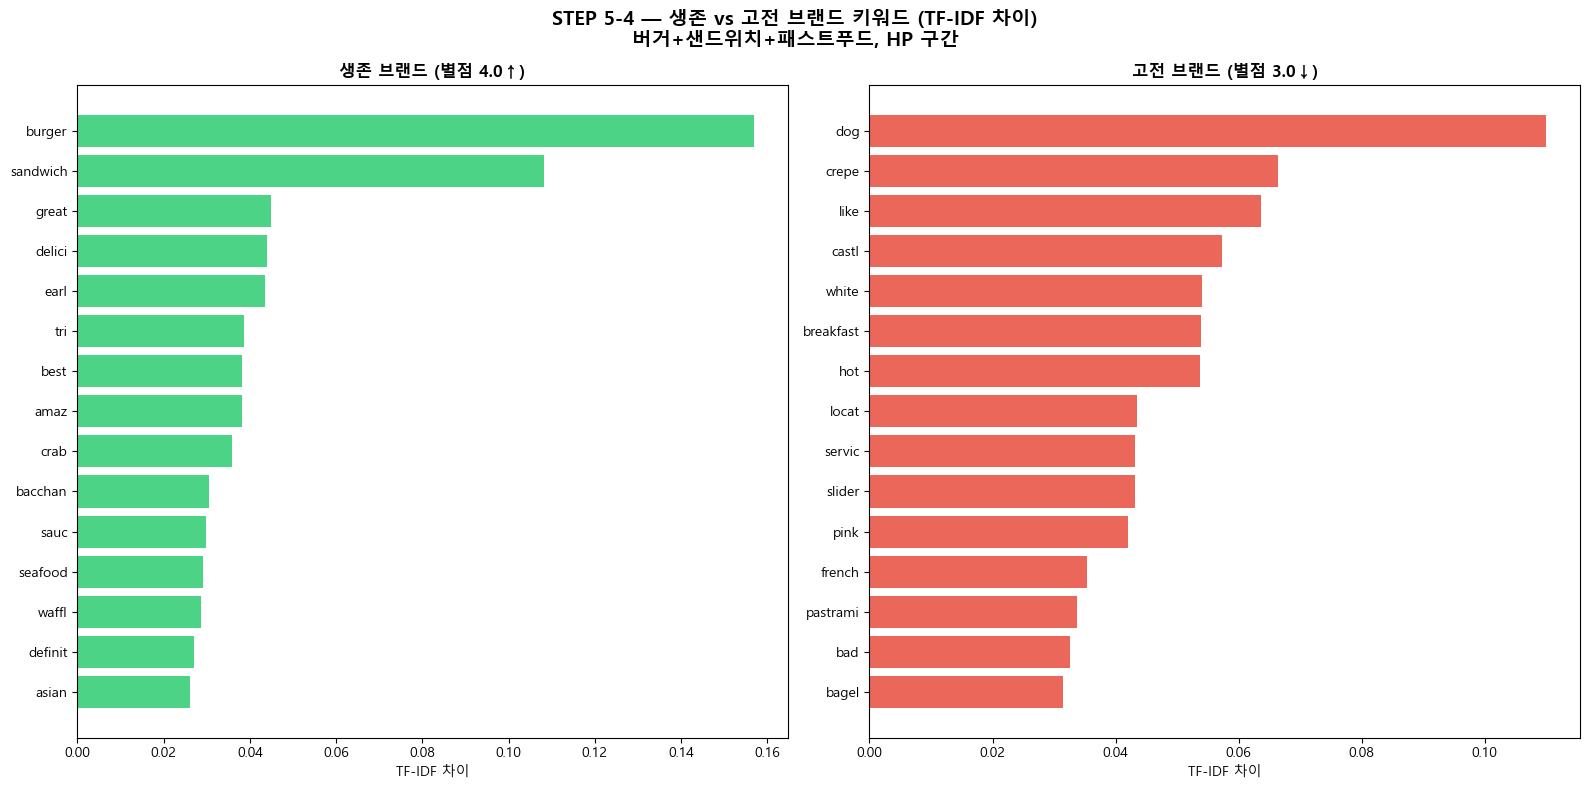

In [11]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 5-4 — 생존 vs 고전 브랜드 키워드 (TF-IDF 차이)\n버거+샌드위치+패스트푸드, HP 구간',
             fontsize=14, fontweight='bold')

for ax, diff, title, color in zip(
    axes,
    [survivor_diff, struggle_diff],
    ['생존 브랜드 (별점 4.0↑)', '고전 브랜드 (별점 3.0↓)'],
    ['#2ecc71', '#e74c3c']
):
    top = diff.head(15)
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('TF-IDF 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_survival_tfidf.png",
            dpi=150, bbox_inches='tight')
plt.show()

### STEP 5-4 결과 요약 — 생존 vs 고전 브랜드 TF-IDF 키워드

| 구분 | 고유 키워드 | 해석 |
|---|---|---|
| 생존 브랜드 | great, delici, amaz, flavor, sushi, perfect | 음식 품질 + 강한 긍정 표현 |
| 고전 브랜드 | buffet, line, wait, bad, manag, minut | 대기 불만 + 운영 문제 |

팀플과 유사한 방향이나 카지노 노이즈(hotel, casino)가 상대적으로 적게 나타났다.

---
## STEP 5-5. N-gram 분석

단어 단위가 아닌 **구(phrase) 단위**로 생존/고전 브랜드의
언어 패턴 차이를 분석한다.

"fresh ingredients", "long wait time", "friendly staff" 같은
복합 표현을 포착하여 TF-IDF 단어 분석을 보완한다.

- Bigram (2단어 조합): 주요 표현 패턴
- Trigram (3단어 조합): 더 구체적인 경험 표현

In [12]:
def get_top_ngrams(text, n=2, top_k=20):
    vec = CountVectorizer(
        ngram_range=(n, n),
        max_features=10000,
        stop_words='english'
    ).fit([text])
    bow = vec.transform([text])
    freq = pd.Series(
        bow.toarray()[0],
        index=vec.get_feature_names_out()
    ).sort_values(ascending=False)
    return freq.head(top_k)

# Bigram
print("=== 생존 브랜드 Bigram 상위 20개 ===")
s_bigram = get_top_ngrams(survivor_text, n=2)
print(s_bigram.to_string())

print("\n=== 고전 브랜드 Bigram 상위 20개 ===")
g_bigram = get_top_ngrams(struggle_text, n=2)
print(g_bigram.to_string())

print("\n=== 생존 브랜드 Trigram 상위 20개 ===")
s_trigram = get_top_ngrams(survivor_text, n=3)
print(s_trigram.to_string())

print("\n=== 고전 브랜드 Trigram 상위 20개 ===")
g_trigram = get_top_ngrams(struggle_text, n=3)
print(g_trigram.to_string())

=== 생존 브랜드 Bigram 상위 20개 ===
crab leg            2722
realli good         1672
pretti good         1435
buffet vega         1425
earl sandwich       1373
best buffet         1366
prime rib           1294
wait line           1005
sweet potato         982
grand lux            975
highli recommend     966
onion ring           955
planet hollywood     951
custom servic        928
bachi burger         925
chicken waffl        905
wait minut           901
tast like            892
long line            884
servic great         846

=== 고전 브랜드 Bigram 상위 20개 ===
hot dog             1206
white castl         1054
custom servic        521
prime rib            485
pretti good          452
crab leg             445
tast like            411
new york             382
realli good          368
corn beef            336
look like            321
wait minut           315
crepe station        294
late night           267
feel like            266
onion ring           258
chili chees          257
wait line       

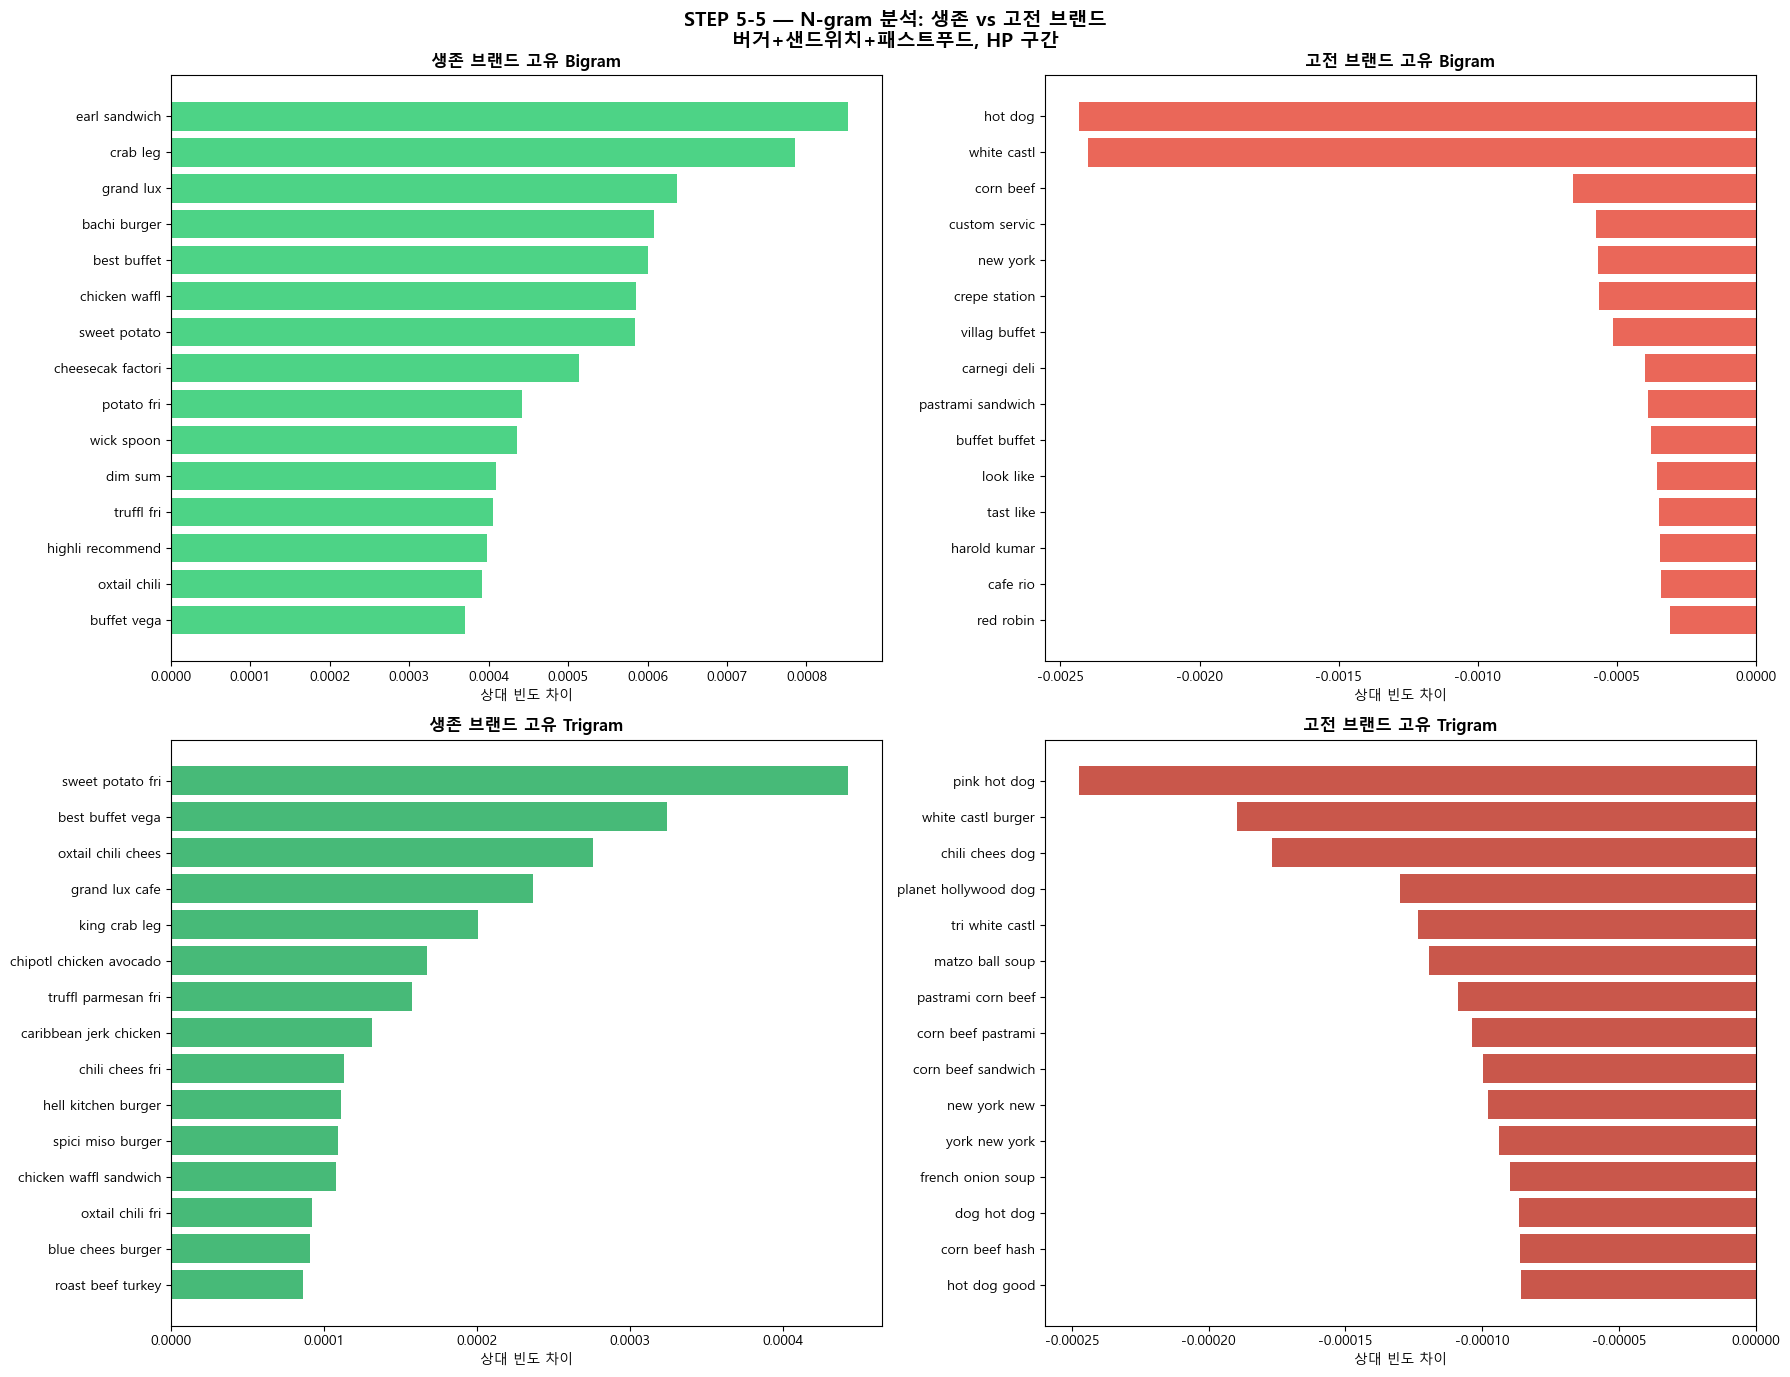

저장 완료: step5_burger_ngram.png


In [13]:
# N-gram 차이 시각화 (생존 - 고전 상대 빈도)
def ngram_relative_freq(text1, text2, n=2, top_k=15):
    vec = CountVectorizer(
        ngram_range=(n, n),
        max_features=10000,
        stop_words='english'
    ).fit([text1, text2])

    freq1 = pd.Series(
        vec.transform([text1]).toarray()[0] / max(len(text1.split()), 1),
        index=vec.get_feature_names_out()
    )
    freq2 = pd.Series(
        vec.transform([text2]).toarray()[0] / max(len(text2.split()), 1),
        index=vec.get_feature_names_out()
    )
    diff = (freq1 - freq2).sort_values(ascending=False)
    return diff.head(top_k), diff.tail(top_k).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('STEP 5-5 — N-gram 분석: 생존 vs 고전 브랜드\n버거+샌드위치+패스트푸드, HP 구간',
             fontsize=14, fontweight='bold')

# Bigram
s_bi, g_bi = ngram_relative_freq(survivor_text, struggle_text, n=2)
axes[0][0].barh(s_bi.index[::-1], s_bi.values[::-1], color='#2ecc71', alpha=0.85)
axes[0][0].set_title('생존 브랜드 고유 Bigram', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('상대 빈도 차이')

axes[0][1].barh(g_bi.index[::-1], g_bi.values[::-1], color='#e74c3c', alpha=0.85)
axes[0][1].set_title('고전 브랜드 고유 Bigram', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('상대 빈도 차이')

# Trigram
s_tri, g_tri = ngram_relative_freq(survivor_text, struggle_text, n=3)
axes[1][0].barh(s_tri.index[::-1], s_tri.values[::-1], color='#27ae60', alpha=0.85)
axes[1][0].set_title('생존 브랜드 고유 Trigram', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('상대 빈도 차이')

axes[1][1].barh(g_tri.index[::-1], g_tri.values[::-1], color='#c0392b', alpha=0.85)
axes[1][1].set_title('고전 브랜드 고유 Trigram', fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('상대 빈도 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_ngram.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_ngram.png")

### STEP 5-5 결과 요약 — N-gram 분석

**생존 브랜드 고유 표현:**
- `crab leg`, `sweet potato fry`, `truffle parmesan fry` → 시그니처 메뉴 전문성
- `bachi burger`, `spicy miso burger`, `hell kitchen burger` → 차별화된 버거 메뉴
- `worth every penny`, `highly recommend` → 강한 가치 표현

**고전 브랜드 고유 표현:**
- `hot dog`, `white castle`, `pink hot dog` → 특색 없는 저가 메뉴
- `wait minute`, `long line`, `custom service` → 대기/서비스 불만
- `corn beef`, `pastrami` → 특정 델리 메뉴 (초기 특성)

> TF-IDF 단어 분석에서 보이지 않던 **"시그니처 메뉴"** 차별화가 N-gram에서 선명하게 드러났다.

---
## STEP 5-6. Sentiment Intensity 분석

VADER로 리뷰별 감정 강도를 측정하여
생존/고전 브랜드의 감정 분포 차이를 분석한다.

TF-IDF는 단어 빈도만 보지만 Sentiment Intensity는
**얼마나 강하게 긍정/부정을 표현하는지**를 포착한다.

- compound score: -1(매우 부정) ~ +1(매우 긍정)
- Mann-Whitney U 검정으로 두 그룹 분포 차이 검증

In [14]:
analyzer = SentimentIntensityAnalyzer()

# 리뷰별 VADER 점수 계산 (원본 텍스트 사용)
review_hp_with_text = review_cleaned.merge(
    hp_labeled[['business_id', 'survival_group']],
    on='business_id', how='inner'
)

print("VADER 감정 강도 계산 중...")
review_hp_with_text['vader_compound'] = review_hp_with_text['text'].apply(
    lambda t: analyzer.polarity_scores(str(t))['compound']
    if pd.notna(t) else np.nan
)

# 그룹별 분포
survivor_vader = review_hp_with_text[
    review_hp_with_text['survival_group'] == '생존'
]['vader_compound'].dropna()
struggle_vader = review_hp_with_text[
    review_hp_with_text['survival_group'] == '고전'
]['vader_compound'].dropna()

print(f"\n=== Sentiment Intensity 분포 ===")
print(f"\n생존 브랜드 (n={len(survivor_vader):,}개):")
print(survivor_vader.describe().round(4))
print(f"\n고전 브랜드 (n={len(struggle_vader):,}개):")
print(struggle_vader.describe().round(4))

# Mann-Whitney U 검정
stat, p = mannwhitneyu(survivor_vader, struggle_vader, alternative='two-sided')
print(f"\nMann-Whitney U 검정:")
print(f"  U-statistic: {stat:.2f}")
print(f"  p-value    : {p:.4f}")
print(f"  유의미     : {'✅ p<0.05' if p < 0.05 else '❌ p≥0.05'}")

VADER 감정 강도 계산 중...

=== Sentiment Intensity 분포 ===

생존 브랜드 (n=30,913개):
count    30913.0000
mean         0.7377
std          0.4576
min         -0.9970
25%          0.7777
50%          0.9324
75%          0.9764
max          0.9998
Name: vader_compound, dtype: float64

고전 브랜드 (n=9,982개):
count    9982.0000
mean        0.4542
std         0.6547
min        -0.9964
25%         0.0000
50%         0.8171
75%         0.9499
max         0.9996
Name: vader_compound, dtype: float64

Mann-Whitney U 검정:
  U-statistic: 200047343.50
  p-value    : 0.0000
  유의미     : ✅ p<0.05


### STEP 5-6 결과 요약 — Sentiment Intensity

| 지표 | 생존 브랜드 | 고전 브랜드 |
|---|---|---|
| 평균 compound | **0.738** | 0.454 |
| 중앙값 | **0.932** | 0.817 |
| 25%ile | **0.778** | 0.000 |
| Mann-Whitney p | **0.000 ✅** | - |

고전 브랜드 리뷰의 25%가 중립(0) 이하.
생존 브랜드는 리뷰 대부분이 강한 긍정(25%ile=0.778).
단순히 긍정 리뷰가 많은 게 아니라 **감정 강도** 자체가 다르다.

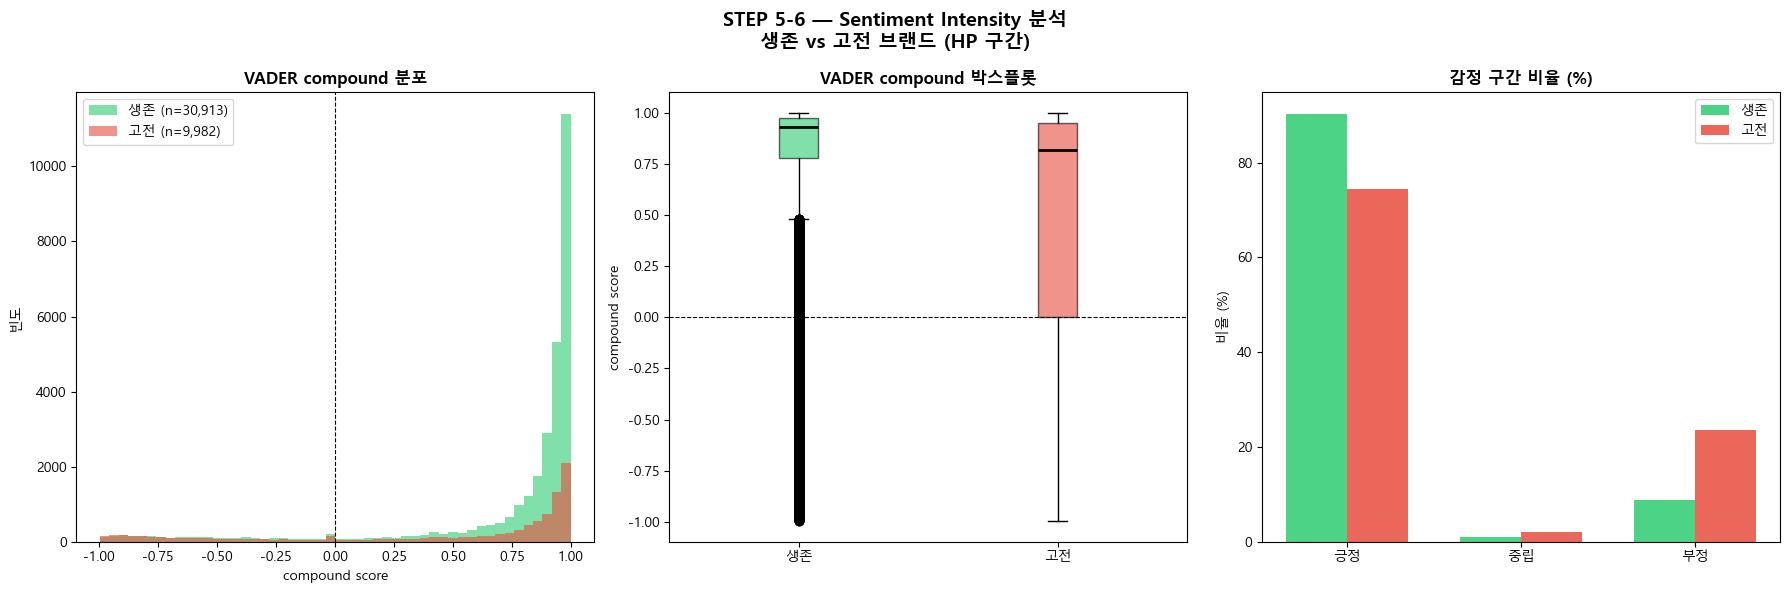

저장 완료: step5_burger_sentiment_intensity.png


In [15]:
# Sentiment Intensity 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('STEP 5-6 — Sentiment Intensity 분석\n생존 vs 고전 브랜드 (HP 구간)',
             fontsize=14, fontweight='bold')

# 1. 분포 히스토그램
axes[0].hist(survivor_vader, bins=50, alpha=0.6,
             color='#2ecc71', label=f'생존 (n={len(survivor_vader):,})')
axes[0].hist(struggle_vader, bins=50, alpha=0.6,
             color='#e74c3c', label=f'고전 (n={len(struggle_vader):,})')
axes[0].set_title('VADER compound 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('compound score')
axes[0].set_ylabel('빈도')
axes[0].legend()
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)

# 2. 박스플롯
axes[1].boxplot([survivor_vader, struggle_vader],
                labels=['생존', '고전'],
                patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
boxes = axes[1].patches
boxes[1].set_facecolor('#e74c3c')
axes[1].set_title('VADER compound 박스플롯', fontsize=12, fontweight='bold')
axes[1].set_ylabel('compound score')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

# 3. 감정 구간 비율
def sentiment_category(score):
    if score >= 0.05:
        return '긍정'
    elif score <= -0.05:
        return '부정'
    else:
        return '중립'

s_cat = survivor_vader.apply(sentiment_category).value_counts(normalize=True) * 100
g_cat = struggle_vader.apply(sentiment_category).value_counts(normalize=True) * 100

cats = ['긍정', '중립', '부정']
x = np.arange(len(cats))
width = 0.35
axes[2].bar(x - width/2,
            [s_cat.get(c, 0) for c in cats],
            width, label='생존', color='#2ecc71', alpha=0.85)
axes[2].bar(x + width/2,
            [g_cat.get(c, 0) for c in cats],
            width, label='고전', color='#e74c3c', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(cats)
axes[2].set_title('감정 구간 비율 (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('비율 (%)')
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_sentiment_intensity.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_sentiment_intensity.png")

---
## STEP 5-7. Topic Modeling (LDA)

LDA(Latent Dirichlet Allocation)로 생존/고전 브랜드 리뷰의
잠재 주제 구조를 분석한다.

TF-IDF가 "어떤 단어가 많이 나오는가"를 보는 반면,
LDA는 **"어떤 주제로 이야기하는가"**를 파악한다.

- 생존/고전 브랜드 각각 LDA 수행
- 토픽별 주요 단어로 주제 해석
- 두 그룹의 토픽 구조 비교

**토픽 수 선정**: 5개
(버거+샌드+패스트푸드 업종 특성상 음식/서비스/가격/분위기/운영 5개 주제로 수렴 예상)

In [16]:
N_TOPICS = 5
N_TOP_WORDS = 10

def run_lda(texts, n_topics=N_TOPICS, n_top_words=N_TOP_WORDS, label=''):
    # CountVectorizer
    vec = CountVectorizer(
        max_features=3000,
        min_df=5,
        max_df=0.95,
        stop_words='english'
    )
    dtm = vec.fit_transform(texts)
    terms = vec.get_feature_names_out()

    # LDA
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        max_iter=20
    )
    lda.fit(dtm)

    print(f"\n{'='*60}")
    print(f"[{label}] LDA 토픽 분석 (토픽 수={n_topics})")
    print(f"{'='*60}")
    for i, topic in enumerate(lda.components_):
        top_words = [terms[j] for j in topic.argsort()[:-n_top_words-1:-1]]
        print(f"  Topic {i+1}: {', '.join(top_words)}")

    return lda, vec, dtm

# 생존 브랜드 리뷰
survivor_texts = review_hp_with_text[
    review_hp_with_text['survival_group'] == '생존'
]['text_clean'].dropna().tolist()

# 고전 브랜드 리뷰
struggle_texts = review_hp_with_text[
    review_hp_with_text['survival_group'] == '고전'
]['text_clean'].dropna().tolist()

lda_s, vec_s, dtm_s = run_lda(survivor_texts, label='생존 브랜드')
lda_g, vec_g, dtm_g = run_lda(struggle_texts, label='고전 브랜드')


[생존 브랜드] LDA 토픽 분석 (토픽 수=5)
  Topic 1: fri, chicken, good, chees, sauc, like, flavor, waffl, sweet, tast
  Topic 2: burger, sandwich, good, vega, fri, tri, like, earl, best, realli
  Topic 3: wait, servic, tabl, minut, like, line, seat, peopl, server, good
  Topic 4: great, good, servic, pizza, love, vega, restaur, price, menu, friendli
  Topic 5: buffet, crab, good, dessert, line, vega, tri, wait, best, station

[고전 브랜드] LDA 토픽 분석 (토픽 수=5)
  Topic 1: sandwich, good, chicken, pizza, like, fri, pastrami, eat, meat, beef
  Topic 2: burger, white, castl, fri, slider, like, good, tri, tast, vega
  Topic 3: dog, hot, good, pink, chees, chili, like, vega, fri, burrito
  Topic 4: servic, wait, minut, custom, like, tabl, drink, manag, peopl, locat
  Topic 5: buffet, good, breakfast, crepe, like, vega, realli, dessert, line, station


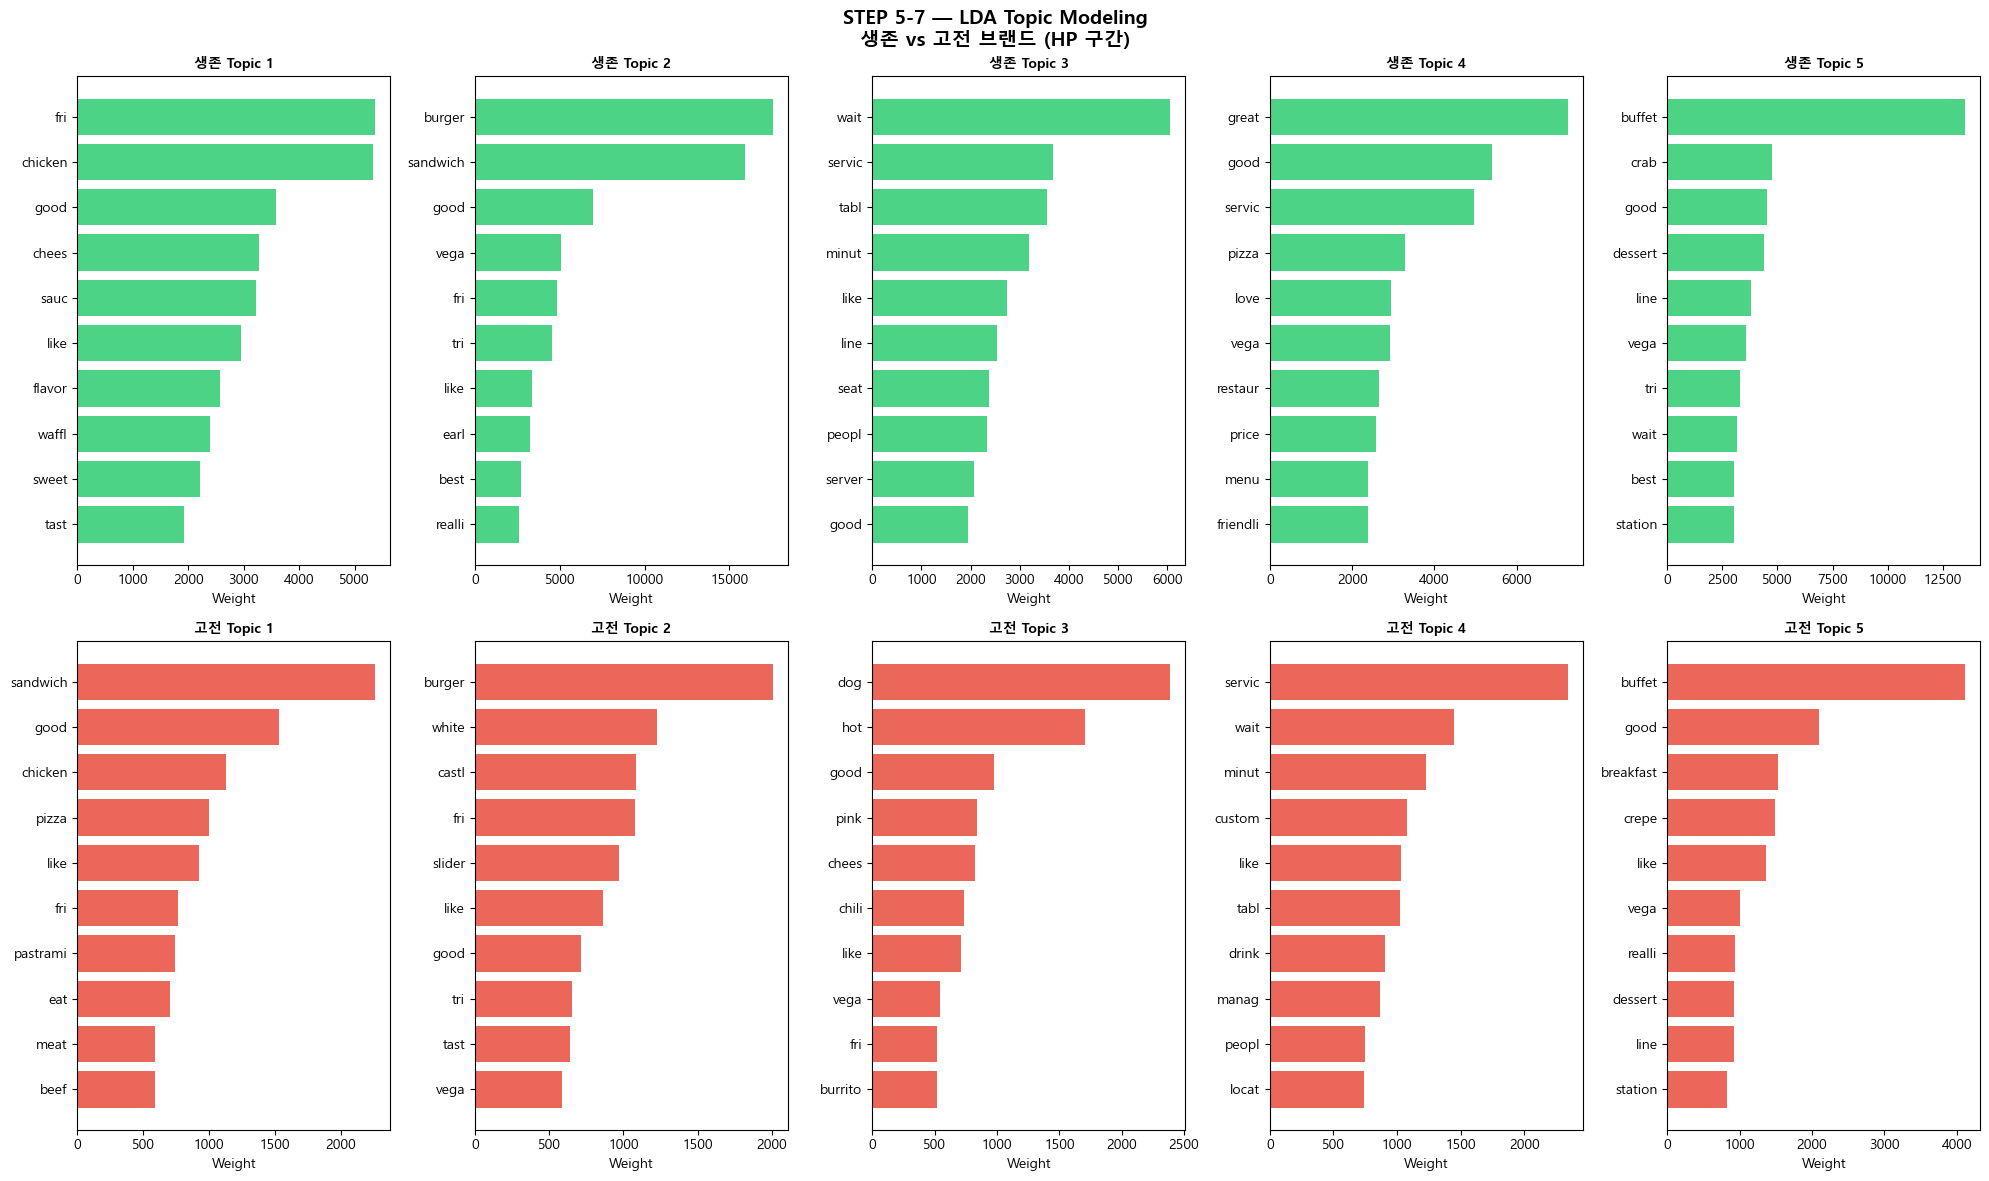

저장 완료: step5_burger_lda.png


In [17]:
# LDA 토픽 시각화
def plot_lda_topics(lda, vec, label, color, ax_list):
    terms = vec.get_feature_names_out()
    for i, (topic, ax) in enumerate(zip(lda.components_, ax_list)):
        top_idx = topic.argsort()[:-N_TOP_WORDS-1:-1]
        top_words = [terms[j] for j in top_idx]
        top_weights = [topic[j] for j in top_idx]
        ax.barh(top_words[::-1], top_weights[::-1],
                color=color, alpha=0.85)
        ax.set_title(f'{label} Topic {i+1}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Weight')

fig, axes = plt.subplots(2, N_TOPICS, figsize=(20, 12))
fig.suptitle('STEP 5-7 — LDA Topic Modeling\n생존 vs 고전 브랜드 (HP 구간)',
             fontsize=14, fontweight='bold')

plot_lda_topics(lda_s, vec_s, '생존', '#2ecc71', axes[0])
plot_lda_topics(lda_g, vec_g, '고전', '#e74c3c', axes[1])

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_lda.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_lda.png")

### STEP 5-7 결과 요약 — LDA Topic Modeling

| 그룹 | 주요 토픽 | 특징 |
|---|---|---|
| 생존 브랜드 | 특색 메뉴 / 시그니처 버거 / 서비스 경험 / 전반적 만족 / 고급 뷔페 | 음식과 경험 중심 |
| 고전 브랜드 | 단순 샌드위치 / 저가 버거 / 핫도그 / 서비스 불만 / 뷔페 | 저가·특색없는 메뉴 + 운영 불만 |

**핵심 차이**: 생존 브랜드 서비스 토픽은 `server, seat, table` (경험),
고전 브랜드 서비스 토픽은 `wait, minute, manager, location` (불만).

---
## STEP 5-8. 프랜차이즈 차별화 분석

HP 구간에서 살아남은 독립 버거 브랜드가
프랜차이즈와 어떤 점에서 언어적으로 차별화되는지 분석한다.

**핵심 질문**: 맥도날드·버거킹 옆에서도 살아남은 독립 버거집,
이들이 프랜차이즈가 하지 못하는 무언가를 하고 있는가?

분석 방법:
1. TF-IDF 차이 — 생존 브랜드 vs 프랜차이즈 키워드
2. N-gram 차이 — 구(phrase) 단위 비교
3. Sentiment Intensity 차이 — 감정 강도 비교

In [ ]:
# 프랜차이즈 리뷰 로드 + 전처리
biz_target = pd.read_csv(f"{PATH_to_data}/biz_target_qsr.csv")
review_all  = pd.read_csv(f"{PATH_to_data}/review_target_qsr.csv")

franchise_ids = biz_target[biz_target['is_franchise'] == True]['business_id']
review_fc = review_all[review_all['business_id'].isin(franchise_ids)].copy()

print(f"프랜차이즈 리뷰 전처리 중... ({len(review_fc):,}개)")
review_fc['text_clean'] = review_fc['text'].apply(preprocess)
franchise_text = ' '.join(review_fc['text_clean'].dropna())
print("완료")

# 생존 브랜드 텍스트 (5-3에서 정의됨)
print(f"\n생존 브랜드 리뷰: {len(survivor_texts):,}개")
print(f"프랜차이즈 리뷰: {len(review_fc):,}개")

프랜차이즈 리뷰 전처리 중... (35,587개)
완료

생존 브랜드 리뷰: 30,913개
프랜차이즈 리뷰: 35,587개


In [20]:
# 1. TF-IDF 차이
corpus_fc = [survivor_text, franchise_text]
vectorizer_fc = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_fc = vectorizer_fc.fit_transform(corpus_fc)
tfidf_fc_df = pd.DataFrame(
    tfidf_fc.toarray(),
    index=['생존브랜드', '프랜차이즈'],
    columns=vectorizer_fc.get_feature_names_out()
)

all_text_fc = (survivor_text + ' ' + franchise_text).split()
word_freq_fc = pd.Series(all_text_fc).value_counts()
valid_words_fc = set(
    w for w, c in word_freq_fc.items()
    if c >= 100 and w.isalpha() and len(w) >= 3
)

vs_franchise = (tfidf_fc_df.loc['생존브랜드'] - tfidf_fc_df.loc['프랜차이즈'])\
               .sort_values(ascending=False)
vs_franchise = vs_franchise[vs_franchise.index.isin(valid_words_fc)]

print("=== 생존 브랜드 차별화 키워드 (프랜차이즈 대비) ===")
print(vs_franchise.head(20).round(4).to_string())
print("\n=== 프랜차이즈 고유 키워드 ===")
print(vs_franchise.tail(20).sort_values().round(4).to_string())

=== 생존 브랜드 차별화 키워드 (프랜차이즈 대비) ===
buffet      0.1905
vega        0.0859
crab        0.0678
dessert     0.0667
good        0.0647
sandwich    0.0633
tri         0.0590
line        0.0549
earl        0.0455
worth       0.0454
best        0.0443
delici      0.0428
seafood     0.0426
price       0.0425
great       0.0415
leg         0.0395
amaz        0.0393
select      0.0389
definit     0.0388
dinner      0.0386

=== 프랜차이즈 고유 키워드 ===
locat      -0.1487
fri        -0.0939
shake      -0.0853
fast       -0.0813
drive      -0.0756
custom     -0.0692
shack      -0.0615
burger     -0.0583
employe    -0.0555
work       -0.0508
never      -0.0488
manag      -0.0487
thru       -0.0467
servic     -0.0459
chicken    -0.0456
innout     -0.0447
clean      -0.0411
mcdonald   -0.0398
guy        -0.0382
like       -0.0374


In [21]:
# 2. N-gram 차이 (생존 브랜드 vs 프랜차이즈)
s_bi_fc, fc_bi = ngram_relative_freq(survivor_text, franchise_text, n=2, top_k=15)
s_tri_fc, fc_tri = ngram_relative_freq(survivor_text, franchise_text, n=3, top_k=15)

print("=== 생존 브랜드 고유 Bigram (프랜차이즈 대비) ===")
print(s_bi_fc.round(6).to_string())
print("\n=== 프랜차이즈 고유 Bigram (생존 브랜드 대비) ===")
print(fc_bi.round(6).to_string())
print("\n=== 생존 브랜드 고유 Trigram ===")
print(s_tri_fc.round(6).to_string())
print("\n=== 프랜차이즈 고유 Trigram ===")
print(fc_tri.round(6).to_string())

=== 생존 브랜드 고유 Bigram (프랜차이즈 대비) ===
crab leg             0.001802
buffet vega          0.000941
best buffet          0.000905
earl sandwich        0.000885
prime rib            0.000849
grand lux            0.000645
planet hollywood     0.000605
chicken waffl        0.000597
bachi burger         0.000581
cheesecak factori    0.000521
wick spoon           0.000516
king crab            0.000437
sweet potato         0.000433
wait line            0.000429
dim sum              0.000416

=== 프랜차이즈 고유 Bigram (생존 브랜드 대비) ===
shake shack      -0.001785
custom servic    -0.001693
anim style       -0.000760
chicken finger   -0.000604
burger fri       -0.000603
taco bell        -0.000528
rais cane        -0.000421
shack burger     -0.000410
texa toast       -0.000400
doubl doubl      -0.000388
sweet tea        -0.000384
innout burger    -0.000375
panda express    -0.000349
burger king      -0.000337
crinkl cut       -0.000331

=== 생존 브랜드 고유 Trigram ===
best buffet vega           0.000409
sweet pot

In [22]:
# 3. Sentiment Intensity 차이 (생존 브랜드 vs 프랜차이즈)
print("프랜차이즈 VADER 계산 중...")
review_fc['vader_compound'] = review_fc['text'].apply(
    lambda t: analyzer.polarity_scores(str(t))['compound']
    if pd.notna(t) else np.nan
)

franchise_vader = review_fc['vader_compound'].dropna()

stat, p = mannwhitneyu(survivor_vader, franchise_vader, alternative='two-sided')

print(f"\n=== Sentiment Intensity 비교 ===")
print(f"\n{'':15} {'생존 브랜드':>15} {'프랜차이즈':>15}")
print(f"{'평균':15} {survivor_vader.mean():>15.4f} {franchise_vader.mean():>15.4f}")
print(f"{'중앙값':15} {survivor_vader.median():>15.4f} {franchise_vader.median():>15.4f}")
print(f"{'25%ile':15} {survivor_vader.quantile(0.25):>15.4f} {franchise_vader.quantile(0.25):>15.4f}")
print(f"{'std':15} {survivor_vader.std():>15.4f} {franchise_vader.std():>15.4f}")
print(f"\nMann-Whitney U p-value: {p:.4f} {'✅' if p < 0.05 else '❌'}")

프랜차이즈 VADER 계산 중...

=== Sentiment Intensity 비교 ===

                         생존 브랜드           프랜차이즈
평균                       0.7377          0.4220
중앙값                      0.9324          0.7987
25%ile                   0.7777         -0.0753
std                      0.4576          0.6737

Mann-Whitney U p-value: 0.0000 ✅


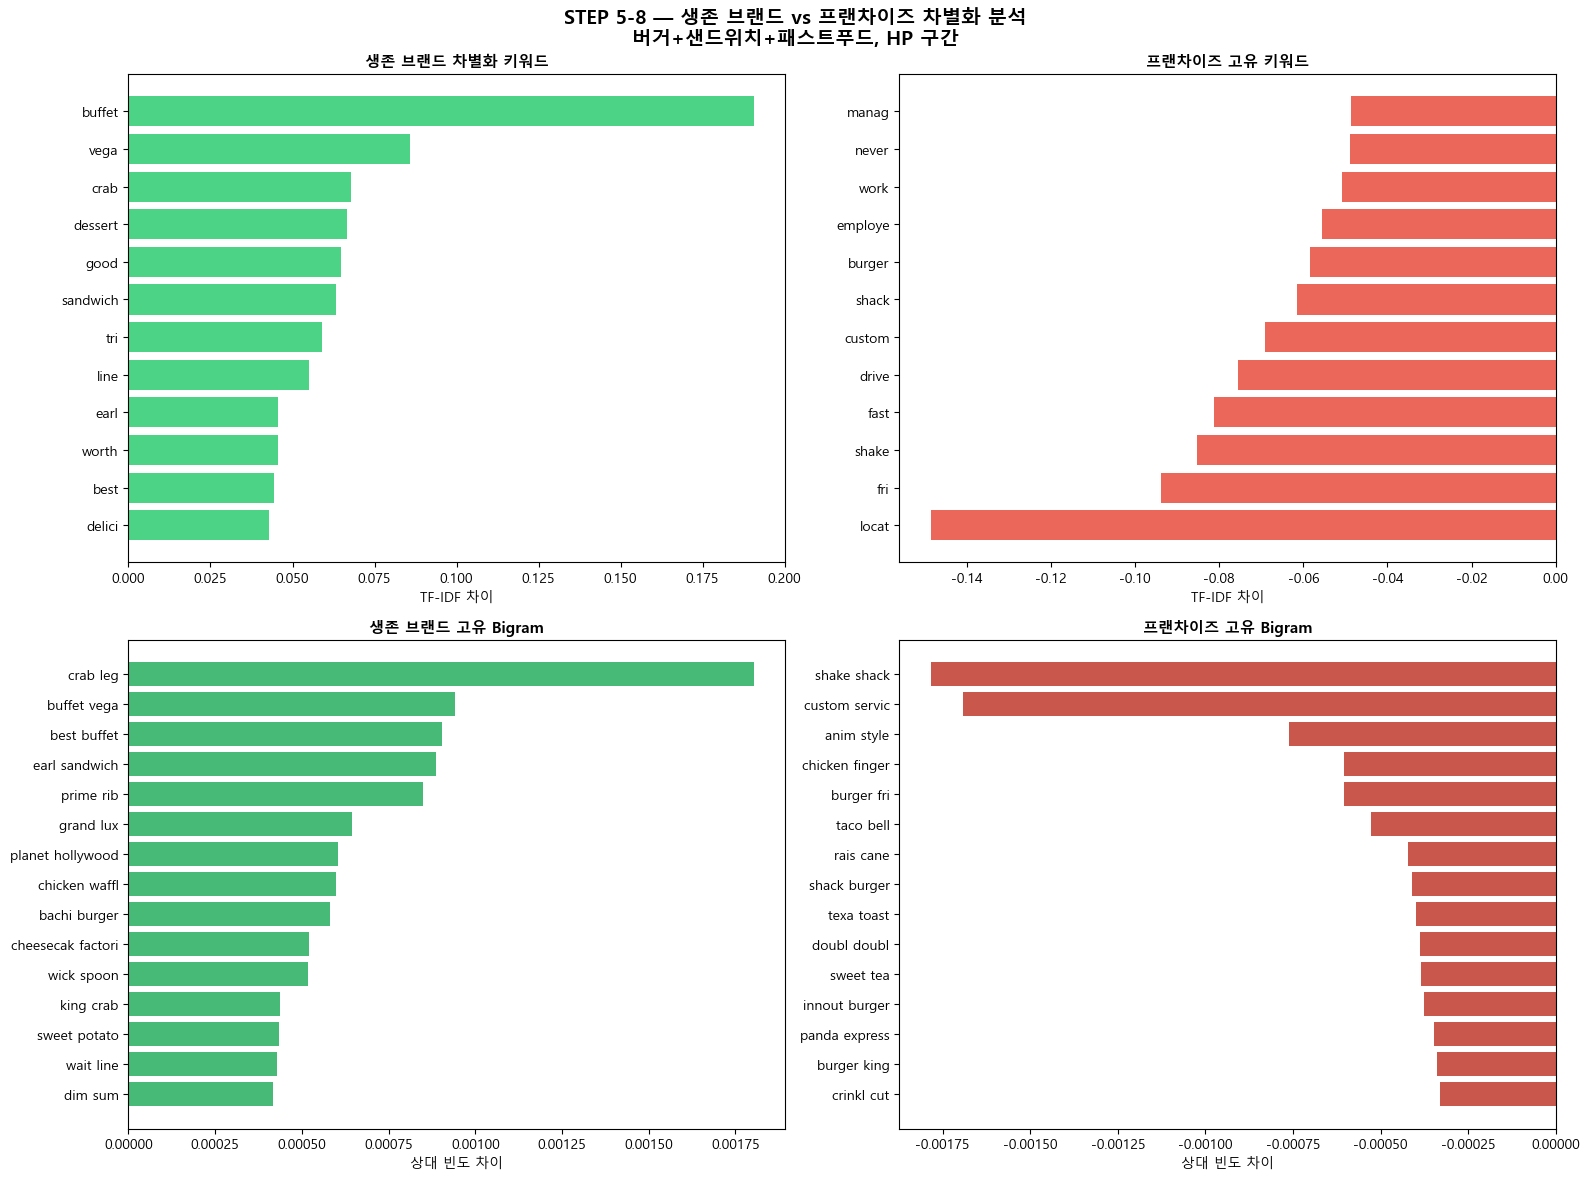

저장 완료: step5_burger_vs_franchise.png


In [23]:
# 시각화 — 생존 브랜드 vs 프랜차이즈 종합
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('STEP 5-8 — 생존 브랜드 vs 프랜차이즈 차별화 분석\n버거+샌드위치+패스트푸드, HP 구간',
             fontsize=14, fontweight='bold')

# TF-IDF 차이
top_sv = vs_franchise.head(12)
axes[0][0].barh(top_sv.index[::-1], top_sv.values[::-1],
                color='#2ecc71', alpha=0.85)
axes[0][0].set_title('생존 브랜드 차별화 키워드', fontsize=11, fontweight='bold')
axes[0][0].set_xlabel('TF-IDF 차이')

top_fc = vs_franchise.tail(12).sort_values()
axes[0][1].barh(top_fc.index, top_fc.values,
                color='#e74c3c', alpha=0.85)
axes[0][1].set_title('프랜차이즈 고유 키워드', fontsize=11, fontweight='bold')
axes[0][1].set_xlabel('TF-IDF 차이')

# N-gram 차이
axes[1][0].barh(s_bi_fc.index[::-1], s_bi_fc.values[::-1],
                color='#27ae60', alpha=0.85)
axes[1][0].set_title('생존 브랜드 고유 Bigram', fontsize=11, fontweight='bold')
axes[1][0].set_xlabel('상대 빈도 차이')

axes[1][1].barh(fc_bi.index[::-1], fc_bi.values[::-1],
                color='#c0392b', alpha=0.85)
axes[1][1].set_title('프랜차이즈 고유 Bigram', fontsize=11, fontweight='bold')
axes[1][1].set_xlabel('상대 빈도 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_vs_franchise.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_vs_franchise.png")

### STEP 5-8 결과 요약 — 프랜차이즈 차별화 분석

**생존 브랜드 차별화 키워드**: buffet, crab, dessert, worth, delici, amaz
**프랜차이즈 고유 키워드**: locat, fast, drive, thru, employe, manag, mcdonald

**Sentiment 비교**

| | 생존 브랜드 | 프랜차이즈 |
|---|---|---|
| 평균 | 0.738 | 0.422 |
| 25%ile | 0.778 | **-0.075** |

프랜차이즈 리뷰 25%가 부정적. 생존 독립 브랜드는 압도적으로 강한 긍정 감정 유발.

---
## STEP 5-9. 시계열 감성 변화 분석

**핵심 질문**: 고전 브랜드 리뷰에서 "한때는 좋았는데" 패턴이 있는가?
폐업 직전 리뷰의 감성점수가 시간에 따라 어떻게 변화하는지 분석한다.

생존 브랜드와 고전 브랜드의 시간에 따른 감성점수 추이를 비교하여
고전 브랜드가 언제부터 부정적 리뷰가 증가하는지 확인한다.

In [24]:
# 리뷰 날짜 정보 로드
review_all_date = pd.read_csv(f"{PATH_to_data}/review_target_burger.csv",
                               usecols=['review_id', 'business_id', 'stars', 'date', 'text'])
review_all_date['date'] = pd.to_datetime(review_all_date['date'])
review_all_date['year_month'] = review_all_date['date'].dt.to_period('M')

# 생존/고전 브랜드 리뷰 날짜 데이터
review_hp_date = review_all_date.merge(
    hp_labeled[['business_id', 'survival_group']],
    on='business_id', how='inner'
)

# VADER 감성점수 계산
print("시계열 VADER 계산 중...")
review_hp_date['vader'] = review_hp_date['text'].apply(
    lambda t: analyzer.polarity_scores(str(t))['compound']
    if pd.notna(t) else np.nan
)

# 월별 평균 감성점수
monthly_sentiment = review_hp_date.groupby(
    ['year_month', 'survival_group']
)['vader'].mean().reset_index()
monthly_sentiment['year_month'] = monthly_sentiment['year_month'].dt.to_timestamp()

print(f"분석 기간: {review_hp_date['date'].min().date()} ~ {review_hp_date['date'].max().date()}")
print(f"월별 데이터 포인트: {len(monthly_sentiment)}개")

시계열 VADER 계산 중...
분석 기간: 2005-01-26 ~ 2017-12-11
월별 데이터 포인트: 287개


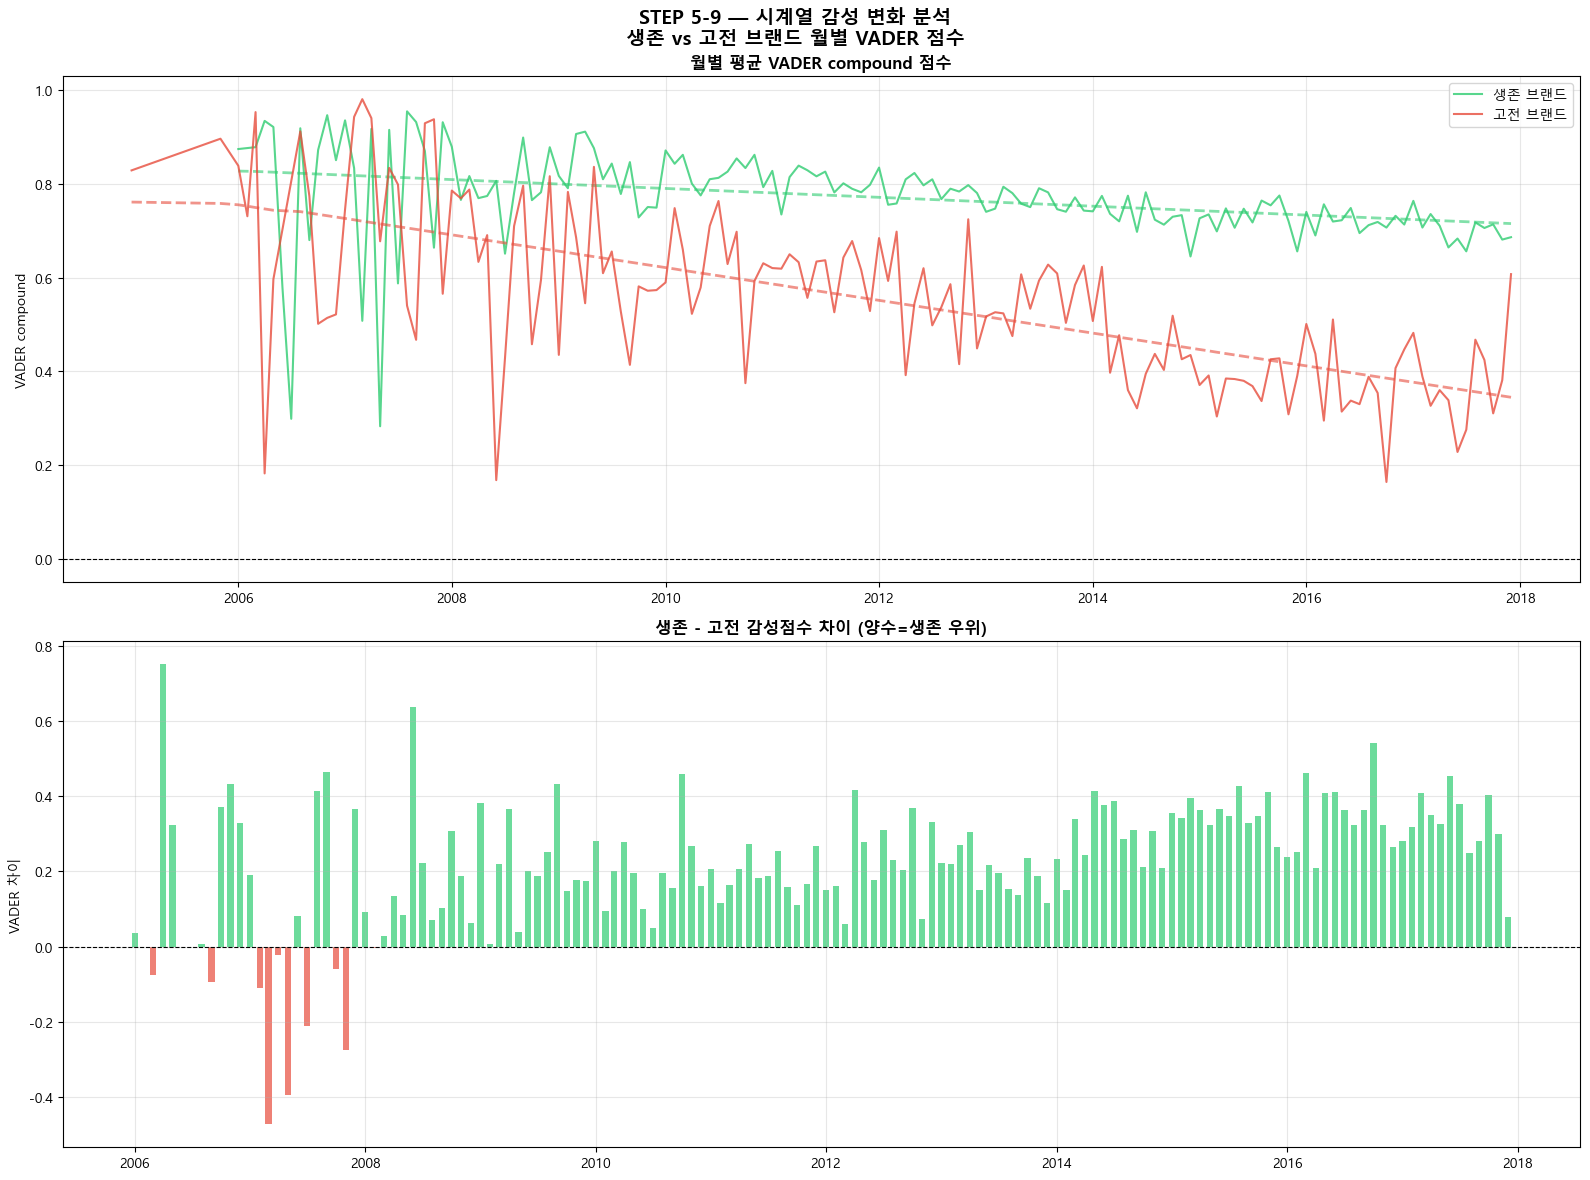

저장 완료: step5_burger_timeseries.png


In [25]:
# 시계열 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('STEP 5-9 — 시계열 감성 변화 분석\n생존 vs 고전 브랜드 월별 VADER 점수',
             fontsize=14, fontweight='bold')

for group, color, label in [
    ('생존', '#2ecc71', '생존 브랜드'),
    ('고전', '#e74c3c', '고전 브랜드')
]:
    data = monthly_sentiment[monthly_sentiment['survival_group'] == group]
    axes[0].plot(data['year_month'], data['vader'],
                 color=color, label=label, alpha=0.8, linewidth=1.5)
    # 추세선
    z = np.polyfit(range(len(data)), data['vader'], 1)
    p_trend = np.poly1d(z)
    axes[0].plot(data['year_month'], p_trend(range(len(data))),
                 color=color, linestyle='--', linewidth=2, alpha=0.6)

axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('월별 평균 VADER compound 점수', fontsize=12, fontweight='bold')
axes[0].set_ylabel('VADER compound')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 차이 (생존 - 고전)
pivot = monthly_sentiment.pivot(
    index='year_month', columns='survival_group', values='vader'
).dropna()
diff = pivot['생존'] - pivot['고전']
axes[1].bar(diff.index, diff.values,
            color=['#2ecc71' if v > 0 else '#e74c3c' for v in diff.values],
            alpha=0.7, width=20)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('생존 - 고전 감성점수 차이 (양수=생존 우위)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('VADER 차이')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_timeseries.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_timeseries.png")

### STEP 5-9 결과 요약 — 시계열 감성 변화

| 지표 | 생존 브랜드 | 고전 브랜드 |
|---|---|---|
| 추세 | 완만한 하락 (0.85→0.70) | **급격한 하락 (0.75→0.35)** |
| 2006~2008 | 일부 고전 브랜드 우위 | 초기엔 좋았음 |
| 2009년 이후 | 지속적 우위 | 지속적 악화 |

> **"한때는 좋았는데" 패턴이 데이터로 확인되었다.**
> 고전 브랜드는 처음부터 나쁜 게 아니라 시간이 지나면서 품질을 유지하지 못해 도태되었다.

---
## STEP 5-10. 프랜차이즈 직접 언급 분석

**핵심 질문**: 생존 브랜드 리뷰에서 프랜차이즈를 직접 비교하는 표현이
고전 브랜드보다 더 많이 나오는가?

"better than McDonald's", "unlike chain restaurants" 같은 표현이
생존 브랜드 리뷰에 더 많다면, 소비자가 독립 브랜드를
**프랜차이즈 대안**으로 의식적으로 선택하고 있다는 증거다.

In [27]:
# 원본 텍스트 기준으로 분석 (소문자 변환)
review_hp_raw = review_all.merge(
    hp_labeled[['business_id', 'survival_group']],
    on='business_id', how='inner'
)
review_hp_raw['text_lower'] = review_hp_raw['text'].str.lower().fillna('')

survivor_raw = ' '.join(
    review_hp_raw[review_hp_raw['survival_group'] == '생존']['text_lower']
)
struggle_raw = ' '.join(
    review_hp_raw[review_hp_raw['survival_group'] == '고전']['text_lower']
)

# 생존/고전 리뷰 수 (정규화용)
n_survivor = (review_hp_raw['survival_group'] == '생존').sum()
n_struggle  = (review_hp_raw['survival_group'] == '고전').sum()

# 프랜차이즈 관련 패턴
patterns = {
    '프랜차이즈 브랜드명': [
        "mcdonald", "burger king", "wendy", "jack in the box",
        "carl's jr", "five guys", "in-n-out", "shake shack"
    ],
    '비교 표현': [
        "better than", "beats", "beats mcdonald",
        "unlike chain", "not a chain", "local spot"
    ],
    '차별화 표현': [
        "homemade", "fresh ingredients", "made from scratch",
        "house made", "locally owned", "family owned", "owner"
    ],
    '부정적 프랜차이즈 비교': [
        "chain restaurant", "fast food chain",
        "corporate", "feels like chain"
    ]
}

print(f"{'패턴':30s} | {'생존(건/만리뷰)':>15} | {'고전(건/만리뷰)':>15} | {'차이':>10}")
print("-" * 75)

results = []
for category, words in patterns.items():
    print(f"\n[{category}]")
    for word in words:
        s_count = survivor_raw.count(word)
        g_count = struggle_raw.count(word)
        s_per_10k = s_count / n_survivor * 10000
        g_per_10k = g_count / n_struggle * 10000
        diff = s_per_10k - g_per_10k
        direction = '생존↑' if diff > 0 else '고전↑'
        print(f"  {word:28s} | {s_per_10k:>15.2f} | {g_per_10k:>15.2f} | {direction} {abs(diff):.2f}")
        results.append({
            '카테고리': category, '패턴': word,
            '생존(만리뷰당)': s_per_10k,
            '고전(만리뷰당)': g_per_10k,
            '차이': diff
        })

results_df = pd.DataFrame(results)

패턴                             |       생존(건/만리뷰) |       고전(건/만리뷰) |         차이
---------------------------------------------------------------------------

[프랜차이즈 브랜드명]
  mcdonald                     |           51.43 |          178.32 | 고전↑ 126.89
  burger king                  |            9.38 |           47.08 | 고전↑ 37.70
  wendy                        |            7.44 |           25.05 | 고전↑ 17.60
  jack in the box              |            2.26 |           13.02 | 고전↑ 10.76
  carl's jr                    |            5.50 |           11.02 | 고전↑ 5.52
  five guys                    |           15.85 |           16.03 | 고전↑ 0.18
  in-n-out                     |           33.32 |           43.08 | 고전↑ 9.76
  shake shack                  |           30.08 |           27.05 | 생존↑ 3.04

[비교 표현]
  better than                  |          374.60 |          334.60 | 생존↑ 40.00
  beats                        |           30.73 |           32.06 | 고전↑ 1.33
  beats mcdonald               |   

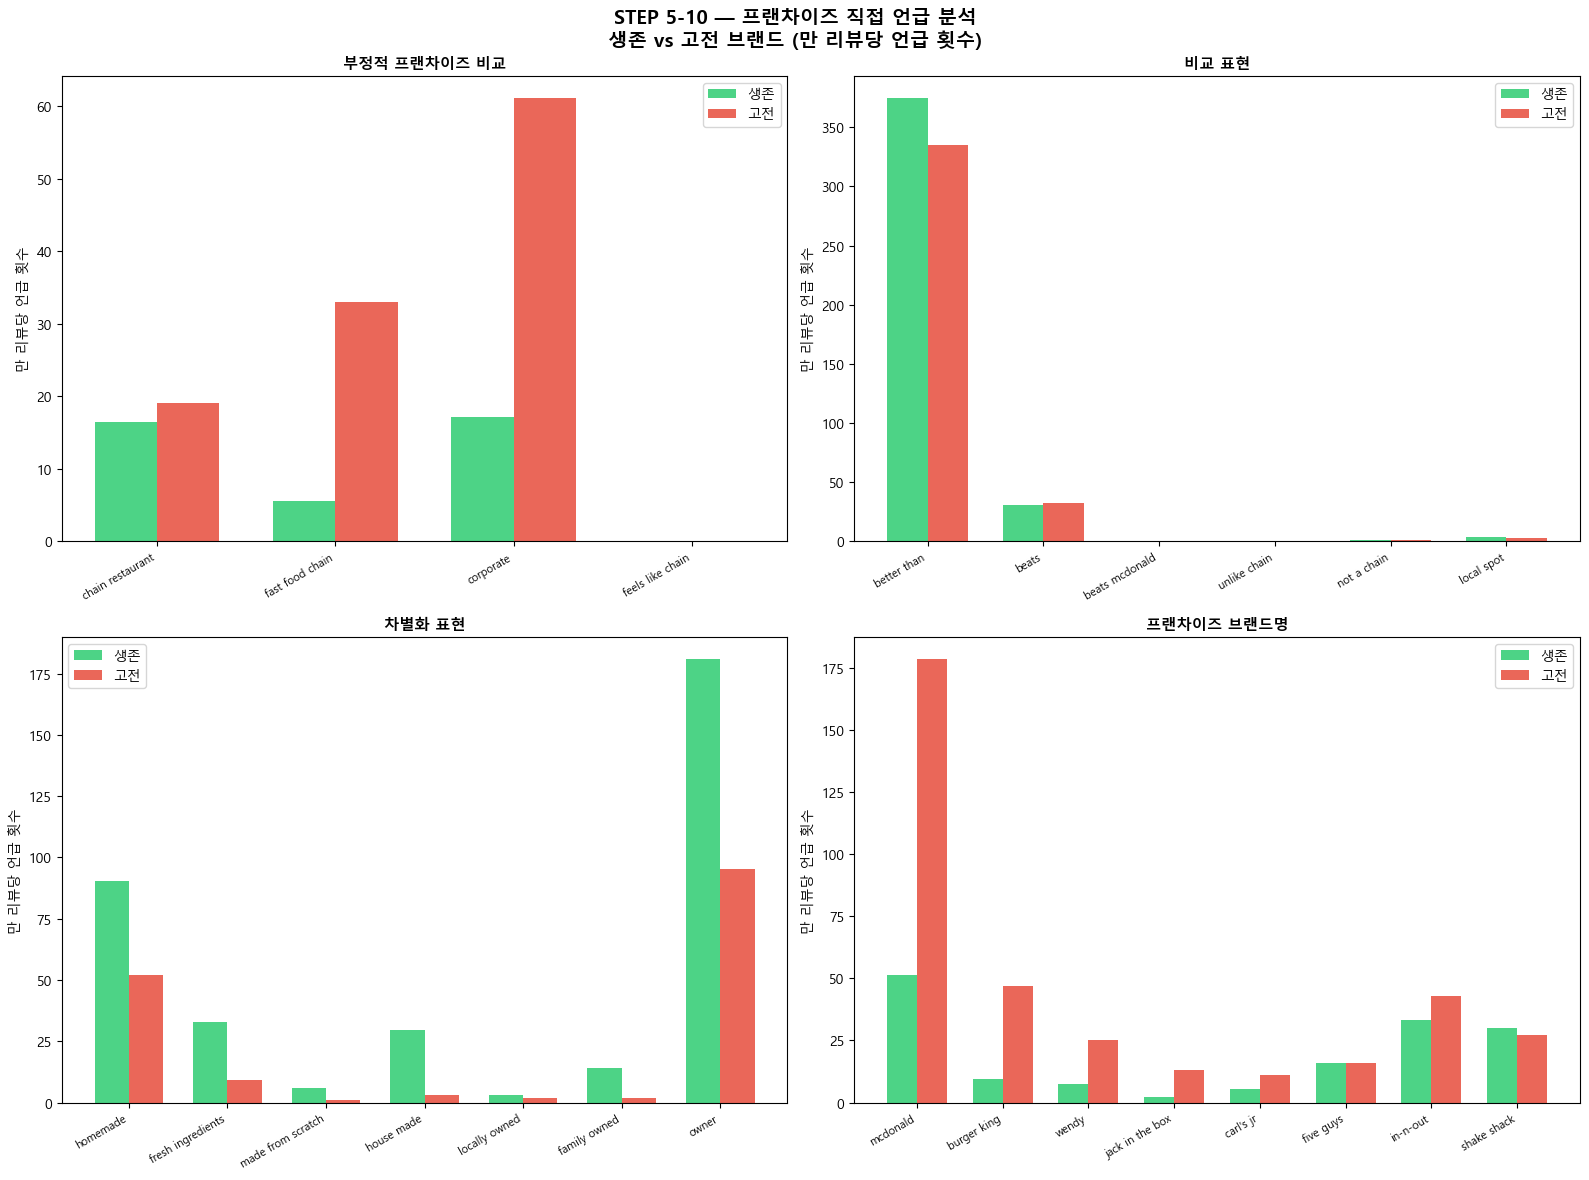

저장 완료: step5_burger_franchise_mention.png


In [28]:
# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('STEP 5-10 — 프랜차이즈 직접 언급 분석\n생존 vs 고전 브랜드 (만 리뷰당 언급 횟수)',
             fontsize=14, fontweight='bold')

for ax, (category, group_df) in zip(
    axes.flatten(),
    results_df.groupby('카테고리')
):
    x = np.arange(len(group_df))
    width = 0.35
    ax.bar(x - width/2, group_df['생존(만리뷰당)'],
           width, label='생존', color='#2ecc71', alpha=0.85)
    ax.bar(x + width/2, group_df['고전(만리뷰당)'],
           width, label='고전', color='#e74c3c', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(group_df['패턴'], rotation=30, ha='right', fontsize=8)
    ax.set_title(category, fontsize=11, fontweight='bold')
    ax.set_ylabel('만 리뷰당 언급 횟수')
    ax.legend()

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_franchise_mention.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_franchise_mention.png")

In [29]:
# McDonald's 언급 리뷰에서 앞뒤 문맥 확인
import re

target_word = "mcdonald"

for group in ['생존', '고전']:
    reviews = review_hp_raw[
        review_hp_raw['survival_group'] == group
    ]['text_lower']
    
    mentions = reviews[reviews.str.contains(target_word, na=False)]
    print(f"\n[{group}] McDonald's 언급 리뷰 샘플 5개:")
    for text in mentions.sample(min(5, len(mentions)), random_state=42):
        # 언급 앞뒤 100자 추출
        idx = text.find(target_word)
        context = text[max(0, idx-50):idx+80]
        print(f"  ...{context}...")
        print()


[생존] McDonald's 언급 리뷰 샘플 5개:
  ...y the burger was average - slightly better than a mcdonalds $4 burger but not as good as a $8 tgi friday's burger.  i've had custo...

  ...g to go out of your way of .. i'd go here only if mcdonald's wasn't 24 hours or if fuku burger ran outta business .. but we all kn...

  ... just go to the monte carlo food court and grab a mcdonald's sandwich or subway instead for less.

if you're staying in ph, stay a...

  ... vietnamese to me.  

fries used are similar to a mcdonald's cut.  they are quite crispy and light.  seasoning used is minimal and...

  ...a better option then mcdonald's if you find yourself in miracle mile, elara, or ph.  ordered four ite...


[고전] McDonald's 언급 리뷰 샘플 5개:
  ...my farm burner burger. food (1\/5) sadly, i think mcdonald's across the street would have been better. :(

people that came in aft...

  ...at excalibur (where i was staying) and luxor were mcdonald's and krispy kreme. my wife and i were in search of late late nig

### STEP 5-10 결과 요약 — 프랜차이즈 직접 언급 분석

**차별화 표현 (만 리뷰당 언급 횟수)**

| 표현 | 생존 | 고전 | 방향 |
|---|---|---|---|
| homemade | 90.6 | 52.1 | 생존↑ |
| fresh ingredients | 32.7 | 9.0 | 생존↑ |
| house made | 29.4 | 3.0 | 생존↑ |
| family owned | 13.9 | 2.0 | 생존↑ |
| owner | 180.8 | 95.2 | 생존↑ |
| corporate | 17.1 | 61.1 | **고전↑** |
| fast food chain | 5.5 | 33.1 | **고전↑** |

**McDonald's 언급 맥락 분석:**
- 생존 브랜드: "better than McDonald's", "blows McDonald's out of the water" → 긍정적 비교
- 고전 브랜드: "McDonald's would have been better", "reminded me of plain McDonald's" → 부정적 비교

> McDonald's가 소비자의 **최소 기준선**으로 작동.
> 생존 브랜드는 이 기준선을 넘었고, 고전 브랜드는 넘지 못했다.

---
## STEP 5-11. 고전 브랜드 시기별 키워드 변화 (원인 파악)

**핵심 질문**: 고전 브랜드는 처음부터 나빴는가, 아니면 시간이 지나면서 나빠졌는가?

5-9 시계열 분석에서 고전 브랜드의 감성점수가 시간이 갈수록
급격히 하락하는 패턴이 확인되었다.
초기(2005~2008) vs 후기(2014~2017) 리뷰를 비교하여
**어떤 변화가 하락을 초래했는지** 텍스트로 파악한다.

분석 방법:
1. 시기별 TF-IDF 차이 — 초기 vs 후기 키워드 변화
2. 시기별 Sentiment Intensity — 감정 강도 변화
3. 하락 시점 리뷰 샘플링 — 실제 리뷰 맥락 확인

In [30]:
# 고전 브랜드 시기 분류
struggle_reviews = review_hp_date[
    review_hp_date['survival_group'] == '고전'
].copy()

early = struggle_reviews[struggle_reviews['date'].dt.year <= 2008]
late  = struggle_reviews[struggle_reviews['date'].dt.year >= 2014]

print(f"초기 리뷰 (2005~2008): {len(early):,}개")
print(f"후기 리뷰 (2014~2017): {len(late):,}개")
print(f"\n초기 평균 VADER: {early['vader'].mean():.4f}")
print(f"후기 평균 VADER: {late['vader'].mean():.4f}")
print(f"VADER 하락폭: {early['vader'].mean() - late['vader'].mean():.4f}")

초기 리뷰 (2005~2008): 297개
후기 리뷰 (2014~2017): 6,582개

초기 평균 VADER: 0.6819
후기 평균 VADER: 0.3817
VADER 하락폭: 0.3001


In [31]:
# 시기별 전처리 텍스트 합치기
early_ids = early['business_id'].unique()
late_ids  = late['business_id'].unique()

print(f"초기 리뷰 업체 수: {len(early_ids)}개")
print(f"후기 리뷰 업체 수: {len(late_ids)}개")
print(f"두 시기 모두 존재하는 업체: {len(set(early_ids) & set(late_ids))}개")

# 전처리된 텍스트 합치기
early_text_clean = review_hp_with_text[
    (review_hp_with_text['survival_group'] == '고전') &
    (review_hp_with_text['business_id'].isin(early_ids))
]['text_clean'].dropna()

late_text_clean = review_hp_with_text[
    (review_hp_with_text['survival_group'] == '고전') &
    (review_hp_with_text['business_id'].isin(late_ids))
]['text_clean'].dropna()

early_text = ' '.join(early_text_clean)
late_text  = ' '.join(late_text_clean)

print(f"\n초기 텍스트 단어 수: {len(early_text.split()):,}개")
print(f"후기 텍스트 단어 수: {len(late_text.split()):,}개")

초기 리뷰 업체 수: 18개
후기 리뷰 업체 수: 65개
두 시기 모두 존재하는 업체: 18개

초기 텍스트 단어 수: 287,405개
후기 텍스트 단어 수: 437,816개


In [33]:
# TF-IDF 차이: 초기 vs 후기
corpus_time = [early_text, late_text]
vectorizer_time = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_time = vectorizer_time.fit_transform(corpus_time)
tfidf_time_df = pd.DataFrame(
    tfidf_time.toarray(),
    index=['초기', '후기'],
    columns=vectorizer_time.get_feature_names_out()
)

# 유효 단어 필터
all_text_time = (early_text + ' ' + late_text).split()
word_freq_time = pd.Series(all_text_time).value_counts()
valid_words_time = set(
    w for w, c in word_freq_time.items()
    if c >= 30 and w.isalpha() and len(w) >= 3
)

# 초기에 많았던 단어 (초기 - 후기)
early_unique = (tfidf_time_df.loc['초기'] - tfidf_time_df.loc['후기'])\
               .sort_values(ascending=False)
early_unique = early_unique[early_unique.index.isin(valid_words_time)]

# 후기에 많아진 단어 (후기 - 초기)
late_unique = (tfidf_time_df.loc['후기'] - tfidf_time_df.loc['초기'])\
              .sort_values(ascending=False)
late_unique = late_unique[late_unique.index.isin(valid_words_time)]

print("=== 초기(2005~2008)에 많았던 단어 ===")
print(early_unique.head(20).round(4).to_string())
print("\n=== 후기(2014~2017)에 많아진 단어 ===")
print(late_unique.head(20).round(4).to_string())

=== 초기(2005~2008)에 많았던 단어 ===
buffet       0.0956
dog          0.0515
crepe        0.0351
hot          0.0252
dessert      0.0192
pink         0.0188
breakfast    0.0185
pizza        0.0174
station      0.0173
french       0.0150
crab         0.0141
pastrami     0.0139
select       0.0131
pari         0.0126
villag       0.0125
rib          0.0125
dinner       0.0121
prime        0.0115
leg          0.0108
vega         0.0101

=== 후기(2014~2017)에 많아진 단어 ===
burger     0.0804
castl      0.0573
white      0.0567
slider     0.0499
fri        0.0455
locat      0.0417
chicken    0.0341
taco       0.0219
burrito    0.0212
fast       0.0212
onion      0.0195
servic     0.0186
custom     0.0179
bagel      0.0176
like       0.0171
tast       0.0164
employe    0.0157
staff      0.0142
frozen     0.0142
first      0.0140


In [34]:
# N-gram 시기별 변화
early_bigram = get_top_ngrams(early_text, n=2, top_k=15)
late_bigram  = get_top_ngrams(late_text, n=2, top_k=15)

print("=== 초기 고전 브랜드 Bigram ===")
print(early_bigram.to_string())
print("\n=== 후기 고전 브랜드 Bigram ===")
print(late_bigram.to_string())

# Bigram 변화 (후기 - 초기 상대 빈도)
late_bi_diff, early_bi_diff = ngram_relative_freq(late_text, early_text, n=2, top_k=12)
print("\n=== 후기에 새로 등장한 Bigram ===")
print(late_bi_diff.round(6).to_string())
print("\n=== 초기에만 있던 Bigram ===")
print(early_bi_diff.round(6).to_string())

=== 초기 고전 브랜드 Bigram ===
hot dog             1179
prime rib            481
crab leg             445
pretti good          324
corn beef            324
new york             322
crepe station        294
realli good          278
buffet vega          252
planet hollywood     240
chili chees          236
buffet buffet        236
custom servic        232
villag buffet        226
tast like            224

=== 후기 고전 브랜드 Bigram ===
hot dog          1206
white castl      1054
custom servic     521
prime rib         485
pretti good       452
crab leg          445
tast like         411
new york          382
realli good       368
corn beef         336
look like         321
wait minut        315
crepe station     294
late night        267
feel like         266

=== 후기에 새로 등장한 Bigram ===
white castl      0.002404
custom servic    0.000383
harold kumar     0.000345
cafe rio         0.000341
red robin        0.000327
east coast       0.000265
chicken ring     0.000260
carn asada       0.000249
chees sli

In [35]:
# 하락 시점(2007~2008) 실제 리뷰 샘플링
drop_period = struggle_reviews[
    (struggle_reviews['date'].dt.year >= 2007) &
    (struggle_reviews['date'].dt.year <= 2008) &
    (struggle_reviews['vader'] < 0.3)
]

print(f"하락 시점 부정 리뷰 수: {len(drop_period)}개")
print(f"\n=== 하락 시점 낮은 감성점수 리뷰 샘플 ===")

# 원본 텍스트 매칭
drop_with_text = drop_period.merge(
    review_hp_raw[['business_id', 'text_lower']].drop_duplicates(),
    on='business_id', how='inner'
).sample(min(5, len(drop_period)), random_state=42)

for _, row in drop_with_text.iterrows():
    print(f"\n날짜: {row['date'].date()} | VADER: {row['vader']:.3f}")
    print(f"  {row['text_lower'][:200]}...")

하락 시점 부정 리뷰 수: 43개

=== 하락 시점 낮은 감성점수 리뷰 샘플 ===

날짜: 2008-02-16 | VADER: 0.294
  i would definitely go to carnegie because i love the pickles...they have so many different kinds...if you ever go get "the woody allen special" and if there is 3 or more people only get 1 to share...i...

날짜: 2007-08-27 | VADER: 0.038
  went for dinner this time and it seemed less noisy. we had about a 30 minute wait. the food was good in quality, better than most buffets and there was a good variety. the creme brûlée was better than...

날짜: 2008-08-21 | VADER: -0.877
  i remember having brunch at le village buffet about 2 years ago and thinking it was one of the better buffets in vegas.  so when i stayed at paris recently, i knew i had to go back to le village for b...

날짜: 2008-07-14 | VADER: -0.555
  first time at the paris buffet. it was a little bit of a wait although the line was not long. it started off really good, until our waitress left and we had her substitute. we had to flag him down for...

날

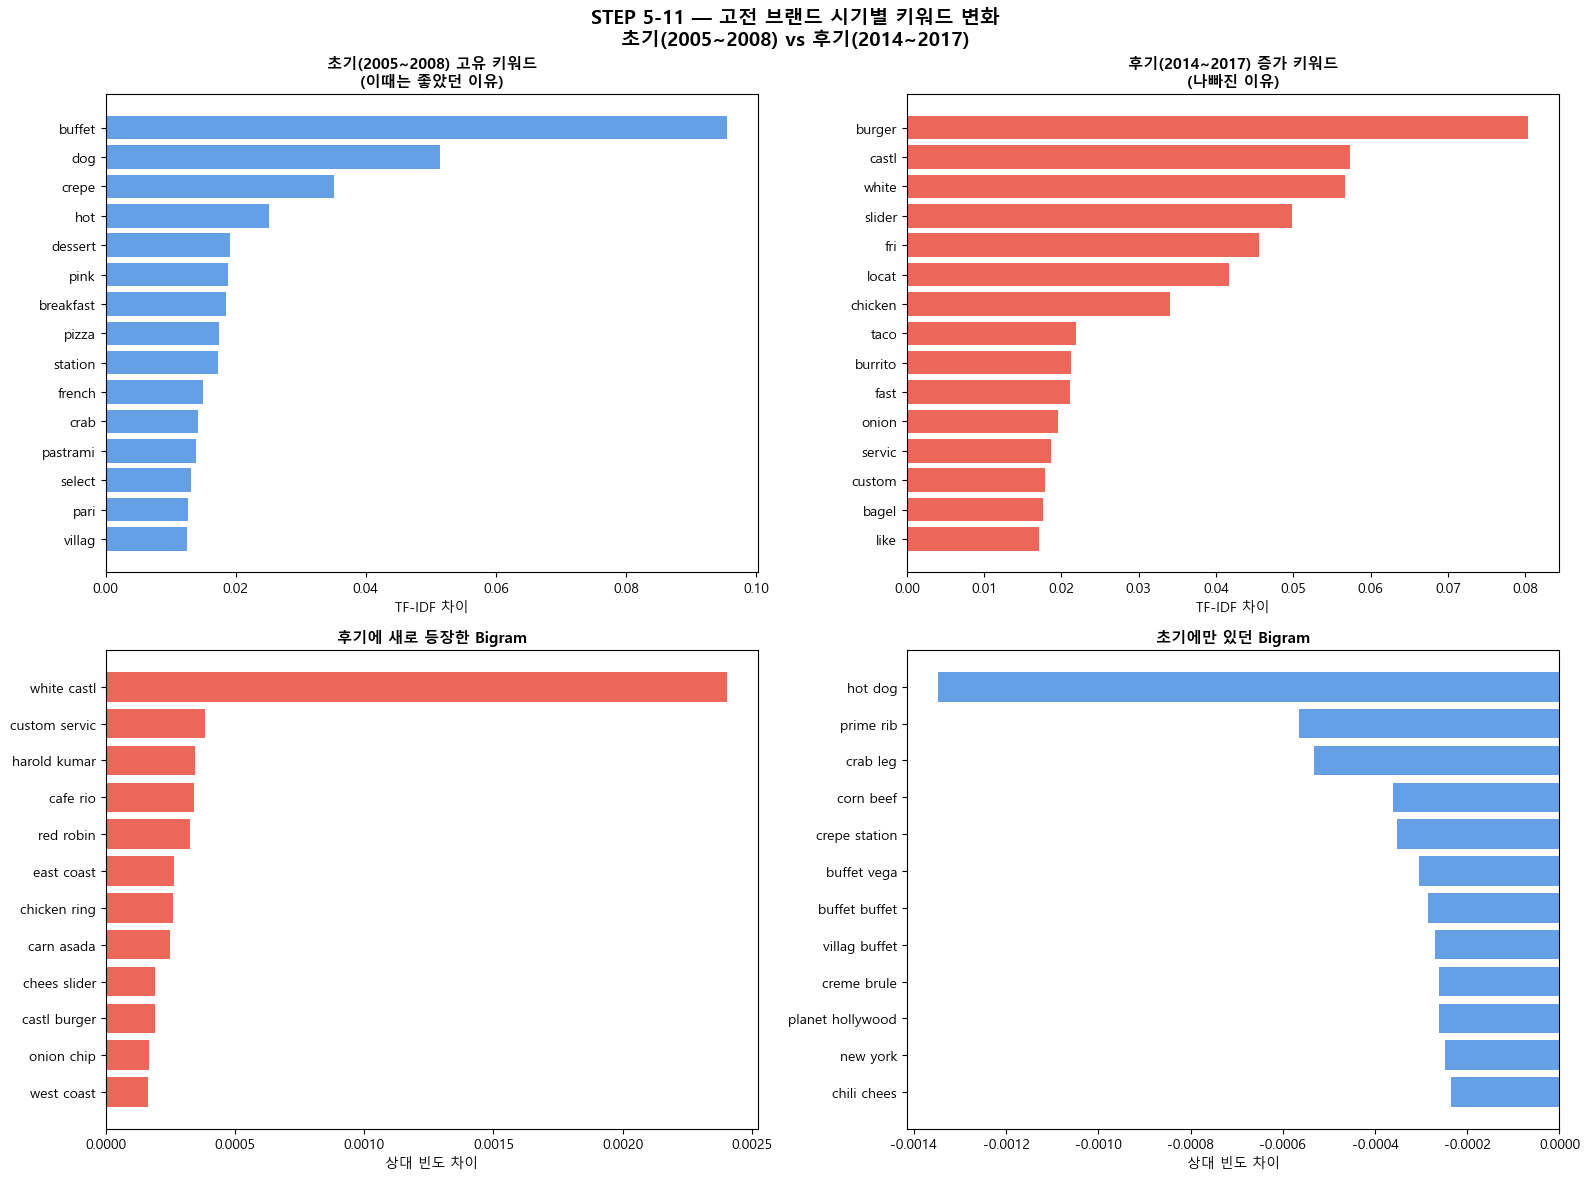

저장 완료: step5_burger_temporal_change.png


In [36]:
# 시각화 — 시기별 변화 종합
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('STEP 5-11 — 고전 브랜드 시기별 키워드 변화\n초기(2005~2008) vs 후기(2014~2017)',
             fontsize=14, fontweight='bold')

# 초기 고유 단어
top_early = early_unique.head(15)
axes[0][0].barh(top_early.index[::-1], top_early.values[::-1],
                color='#4a90e2', alpha=0.85)
axes[0][0].set_title('초기(2005~2008) 고유 키워드\n(이때는 좋았던 이유)',
                     fontsize=11, fontweight='bold')
axes[0][0].set_xlabel('TF-IDF 차이')

# 후기 증가 단어
top_late = late_unique.head(15)
axes[0][1].barh(top_late.index[::-1], top_late.values[::-1],
                color='#e74c3c', alpha=0.85)
axes[0][1].set_title('후기(2014~2017) 증가 키워드\n(나빠진 이유)',
                     fontsize=11, fontweight='bold')
axes[0][1].set_xlabel('TF-IDF 차이')

# Bigram 변화
axes[1][0].barh(late_bi_diff.index[::-1], late_bi_diff.values[::-1],
                color='#e74c3c', alpha=0.85)
axes[1][0].set_title('후기에 새로 등장한 Bigram',
                     fontsize=11, fontweight='bold')
axes[1][0].set_xlabel('상대 빈도 차이')

axes[1][1].barh(early_bi_diff.index[::-1], early_bi_diff.values[::-1],
                color='#4a90e2', alpha=0.85)
axes[1][1].set_title('초기에만 있던 Bigram',
                     fontsize=11, fontweight='bold')
axes[1][1].set_xlabel('상대 빈도 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_temporal_change.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_temporal_change.png")

### STEP 5-11 결과 요약 — 고전 브랜드 시기별 변화

| 시기 | 평균 VADER | 주요 키워드 |
|---|---|---|
| 초기 (2005~2008) | **0.682** | buffet, crepe, crab leg, pastrami, prime rib |
| 후기 (2014~2017) | 0.382 | white castle, burger, employe, staff, frozen |
| 하락폭 | **-0.300** | - |

**초기에만 있던 Bigram**: prime rib, crab leg, crepe station, village buffet, creme brule
**후기에 새로 등장한 Bigram**: white castle, custom service, harold kumar, cafe rio

실제 리뷰 확인:
> "this place has gone downhill from years ago. in the past it was really awesome...
> now it's cafeteria style"

> 고전 브랜드의 하락 경로:
> 초기 차별화 메뉴(뷔페·델리·씨푸드) → 리뷰 급증(소비자 유입) →
> 품질 유지 실패(직원·서비스 문제) → 저가 메뉴로 전환 → 감성점수 급락

---
## STEP 5-12. 생존 브랜드 시기별 키워드 변화 (성공 요인 파악)

**핵심 질문**: 생존 브랜드는 시간이 지나면서 어떻게 더 강해졌는가?

5-11에서 고전 브랜드의 하락 원인을 확인했다.
대칭적으로 생존 브랜드의 초기 vs 후기 리뷰를 비교하여
**장기적으로 높은 평판을 유지한 비결**을 파악한다.

| | 고전 브랜드 (5-11) | 생존 브랜드 (5-12) |
|---|---|---|
| 초기 VADER | 0.682 | ? |
| 후기 VADER | 0.382 | ? |
| 변화 | 급격한 하락 | ? |
| 원인 | 품질 유지 실패 | ? |

In [37]:
# 생존 브랜드 시기 분류
survivor_reviews = review_hp_date[
    review_hp_date['survival_group'] == '생존'
].copy()

early_s = survivor_reviews[survivor_reviews['date'].dt.year <= 2008]
late_s  = survivor_reviews[survivor_reviews['date'].dt.year >= 2014]

print(f"초기 리뷰 (2005~2008): {len(early_s):,}개")
print(f"후기 리뷰 (2014~2017): {len(late_s):,}개")
print(f"\n초기 평균 VADER: {early_s['vader'].mean():.4f}")
print(f"후기 평균 VADER: {late_s['vader'].mean():.4f}")
print(f"VADER 변화폭: {late_s['vader'].mean() - early_s['vader'].mean():.4f}")

print(f"\n초기 리뷰 업체 수: {early_s['business_id'].nunique()}개")
print(f"후기 리뷰 업체 수: {late_s['business_id'].nunique()}개")
print(f"두 시기 모두 존재: {len(set(early_s['business_id'].unique()) & set(late_s['business_id'].unique()))}개")

초기 리뷰 (2005~2008): 340개
후기 리뷰 (2014~2017): 21,915개

초기 평균 VADER: 0.7944
후기 평균 VADER: 0.7167
VADER 변화폭: -0.0777

초기 리뷰 업체 수: 12개
후기 리뷰 업체 수: 63개
두 시기 모두 존재: 12개


In [38]:
# 시기별 전처리 텍스트 합치기
early_s_ids = early_s['business_id'].unique()
late_s_ids  = late_s['business_id'].unique()

early_s_text = ' '.join(
    review_hp_with_text[
        (review_hp_with_text['survival_group'] == '생존') &
        (review_hp_with_text['business_id'].isin(early_s_ids))
    ]['text_clean'].dropna()
)
late_s_text = ' '.join(
    review_hp_with_text[
        (review_hp_with_text['survival_group'] == '생존') &
        (review_hp_with_text['business_id'].isin(late_s_ids))
    ]['text_clean'].dropna()
)

print(f"초기 텍스트 단어 수: {len(early_s_text.split()):,}개")
print(f"후기 텍스트 단어 수: {len(late_s_text.split()):,}개")

# TF-IDF 차이
corpus_s_time = [early_s_text, late_s_text]
vectorizer_s_time = TfidfVectorizer(max_features=5000, min_df=1, max_df=1.0)
tfidf_s_time = vectorizer_s_time.fit_transform(corpus_s_time)
tfidf_s_time_df = pd.DataFrame(
    tfidf_s_time.toarray(),
    index=['초기', '후기'],
    columns=vectorizer_s_time.get_feature_names_out()
)

# 유효 단어 필터
all_text_s_time = (early_s_text + ' ' + late_s_text).split()
word_freq_s_time = pd.Series(all_text_s_time).value_counts()
valid_words_s_time = set(
    w for w, c in word_freq_s_time.items()
    if c >= 30 and w.isalpha() and len(w) >= 3
)

early_s_unique = (tfidf_s_time_df.loc['초기'] - tfidf_s_time_df.loc['후기'])\
                 .sort_values(ascending=False)
early_s_unique = early_s_unique[early_s_unique.index.isin(valid_words_s_time)]

late_s_unique = (tfidf_s_time_df.loc['후기'] - tfidf_s_time_df.loc['초기'])\
                .sort_values(ascending=False)
late_s_unique = late_s_unique[late_s_unique.index.isin(valid_words_s_time)]

print("\n=== 초기(2005~2008)에 많았던 단어 ===")
print(early_s_unique.head(20).round(4).to_string())
print("\n=== 후기(2014~2017)에 많아진 단어 ===")
print(late_s_unique.head(20).round(4).to_string())

초기 텍스트 단어 수: 505,712개
후기 텍스트 단어 수: 1,510,205개

=== 초기(2005~2008)에 많았던 단어 ===
sandwich     0.2517
earl         0.0769
bread        0.0589
night        0.0320
chicken      0.0286
salad        0.0277
club         0.0264
open         0.0261
montagu      0.0258
grand        0.0257
vega         0.0248
lux          0.0241
late         0.0218
soup         0.0215
tuna         0.0211
turkey       0.0206
factori      0.0204
tomato       0.0203
cheesecak    0.0203
hollywood    0.0201

=== 후기(2014~2017)에 많아진 단어 ===
buffet     0.1737
burger     0.1639
wait       0.0789
fri        0.0739
crab       0.0569
line       0.0524
dessert    0.0487
station    0.0407
tri        0.0407
leg        0.0405
seafood    0.0404
worth      0.0397
bacchan    0.0331
egg        0.0294
select     0.0282
section    0.0261
like       0.0255
oxtail     0.0238
sushi      0.0237
oyster     0.0230


In [39]:
# N-gram 시기별 변화
early_s_bigram = get_top_ngrams(early_s_text, n=2, top_k=15)
late_s_bigram  = get_top_ngrams(late_s_text,  n=2, top_k=15)

print("=== 초기 생존 브랜드 Bigram ===")
print(early_s_bigram.to_string())
print("\n=== 후기 생존 브랜드 Bigram ===")
print(late_s_bigram.to_string())

# Bigram 변화
late_s_bi_diff, early_s_bi_diff = ngram_relative_freq(
    late_s_text, early_s_text, n=2, top_k=12
)
print("\n=== 후기에 강화된 Bigram ===")
print(late_s_bi_diff.round(6).to_string())
print("\n=== 초기에만 있던 Bigram ===")
print(early_s_bi_diff.round(6).to_string())

=== 초기 생존 브랜드 Bigram ===
earl sandwich        1368
grand lux             973
planet hollywood      872
cheesecak factori     791
late night            678
realli good           663
open hour             651
roast beef            605
pretti good           603
tuna melt             525
earl club             502
best sandwich         456
sandwich good         444
chipotl chicken       400
hot sandwich          398

=== 후기 생존 브랜드 Bigram ===
crab leg            2722
realli good         1672
pretti good         1435
buffet vega         1425
earl sandwich       1373
best buffet         1366
prime rib           1294
wait line           1005
sweet potato         982
grand lux            975
highli recommend     966
onion ring           955
planet hollywood     951
custom servic        928
bachi burger         925

=== 후기에 강화된 Bigram ===
crab leg          0.001794
buffet vega       0.000926
best buffet       0.000905
prime rib         0.000823
bachi burger      0.000609
wick spoon        0.00050

In [40]:
# 고전 브랜드와 직접 비교
print("=" * 65)
print("생존 vs 고전 브랜드 시기별 VADER 변화 비교")
print("=" * 65)
print(f"\n{'':20} {'초기 VADER':>12} {'후기 VADER':>12} {'변화폭':>12}")
print(f"{'생존 브랜드':20} {early_s['vader'].mean():>12.4f} "
      f"{late_s['vader'].mean():>12.4f} "
      f"{late_s['vader'].mean()-early_s['vader'].mean():>+12.4f}")
print(f"{'고전 브랜드':20} {early['vader'].mean():>12.4f} "
      f"{late['vader'].mean():>12.4f} "
      f"{late['vader'].mean()-early['vader'].mean():>+12.4f}")

생존 vs 고전 브랜드 시기별 VADER 변화 비교

                         초기 VADER     후기 VADER          변화폭
생존 브랜드                     0.7944       0.7167      -0.0777
고전 브랜드                     0.6819       0.3817      -0.3001


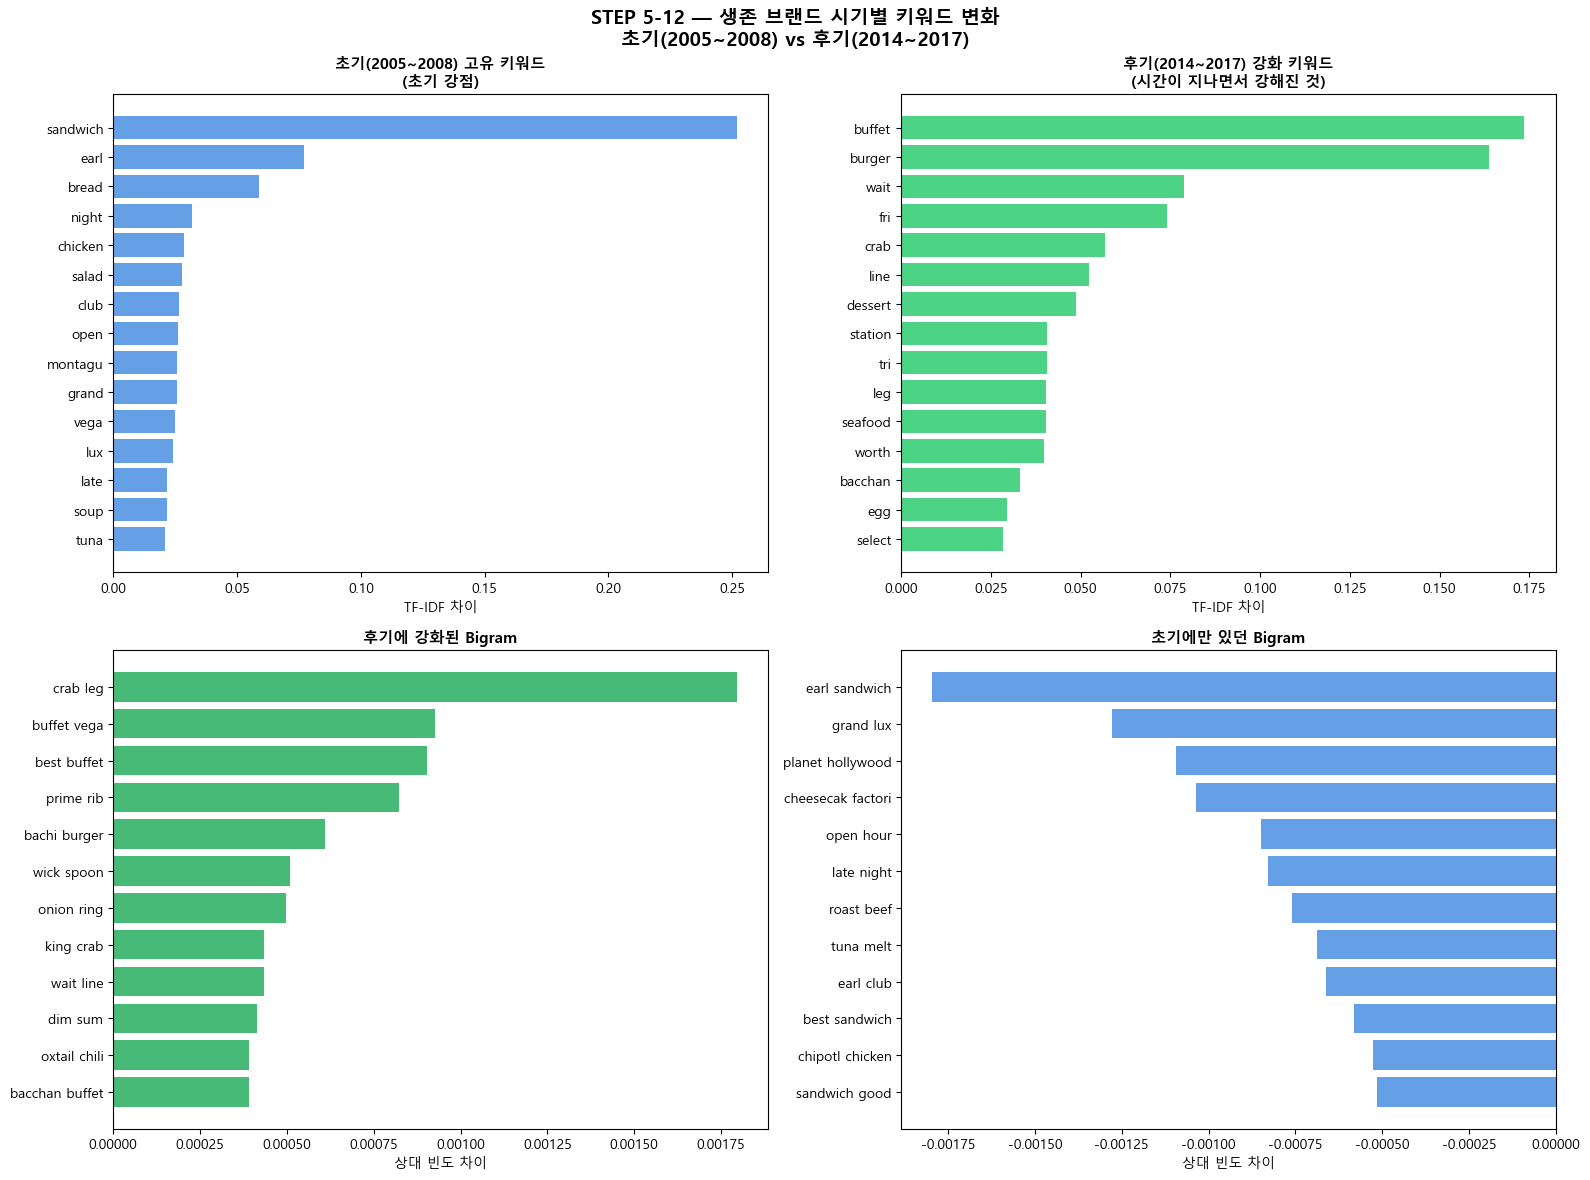

저장 완료: step5_burger_survivor_temporal.png


In [41]:
# 시각화 — 생존 브랜드 시기별 변화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('STEP 5-12 — 생존 브랜드 시기별 키워드 변화\n초기(2005~2008) vs 후기(2014~2017)',
             fontsize=14, fontweight='bold')

# 초기 고유 단어
top_early_s = early_s_unique.head(15)
axes[0][0].barh(top_early_s.index[::-1], top_early_s.values[::-1],
                color='#4a90e2', alpha=0.85)
axes[0][0].set_title('초기(2005~2008) 고유 키워드\n(초기 강점)',
                     fontsize=11, fontweight='bold')
axes[0][0].set_xlabel('TF-IDF 차이')

# 후기 강화 단어
top_late_s = late_s_unique.head(15)
axes[0][1].barh(top_late_s.index[::-1], top_late_s.values[::-1],
                color='#2ecc71', alpha=0.85)
axes[0][1].set_title('후기(2014~2017) 강화 키워드\n(시간이 지나면서 강해진 것)',
                     fontsize=11, fontweight='bold')
axes[0][1].set_xlabel('TF-IDF 차이')

# Bigram 변화
axes[1][0].barh(late_s_bi_diff.index[::-1], late_s_bi_diff.values[::-1],
                color='#27ae60', alpha=0.85)
axes[1][0].set_title('후기에 강화된 Bigram',
                     fontsize=11, fontweight='bold')
axes[1][0].set_xlabel('상대 빈도 차이')

axes[1][1].barh(early_s_bi_diff.index[::-1], early_s_bi_diff.values[::-1],
                color='#4a90e2', alpha=0.85)
axes[1][1].set_title('초기에만 있던 Bigram',
                     fontsize=11, fontweight='bold')
axes[1][1].set_xlabel('상대 빈도 차이')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step5_burger_survivor_temporal.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step5_burger_survivor_temporal.png")

In [42]:
# 초기(2005~2008) 생존 브랜드 업체 목록 확인
early_s_biz = indie_groups[
    indie_groups['business_id'].isin(early_s_ids)
][['business_id', 'name', 'categories', 'stars', 'review_count']].copy()

print(f"초기 생존 브랜드 업체 목록 ({len(early_s_biz)}개):")
print(early_s_biz[['name', 'categories', 'stars', 'review_count']]
      .sort_values('review_count', ascending=False)
      .to_string(index=False))

초기 생존 브랜드 업체 목록 (12개):
                               name                                                                                             categories  stars  review_count
                   Earl of Sandwich Caterers;Sandwiches;Restaurants;Food Delivery Services;Salad;Food;Event Planning & Services;Soup;Wraps    4.5          4869
                     Grand Lux Cafe                             Desserts;American (New);Sandwiches;American (Traditional);Restaurants;Food    4.0          2490
Wolfgang Puck Bar & Grill Las Vegas                                       Nightlife;Salad;Sandwiches;Restaurants;Bars;American (New);Pizza    4.0          1463
                        Stripburger                                                                                    Restaurants;Burgers    4.0           820
                      Vintner Grill    Restaurants;Nightlife;Bars;American (Traditional);Cocktail Bars;Sandwiches;American (New);Wine Bars    4.0           610
      Great Links

### STEP 5-12 해석 주의사항

초기(2005~2008) 생존 브랜드 리뷰는 12개 업체에서만 수집되었으며,
이 중 Earl of Sandwich(리뷰 4,869개)가 전체 텍스트를 압도적으로 지배한다.
따라서 초기 키워드(earl, sandwich, tuna melt 등)는
생존 브랜드 전반의 특성이 아닌 특정 업체의 특성을 반영할 가능성이 높다.

**신뢰도 있는 비교를 위해 초기 기준을 수정한다:**
- 초기: 2010~2012년 (업체 수 충분히 확보된 시기)
- 후기: 2015~2017년

In [43]:
# 연도별 생존 브랜드 리뷰 업체 수 확인
print("=== 생존 브랜드 연도별 리뷰 업체 수 ===")
yearly = survivor_reviews.groupby(survivor_reviews['date'].dt.year).agg(
    리뷰수=('vader', 'count'),
    업체수=('business_id', 'nunique'),
    평균VADER=('vader', 'mean')
).round(4)
print(yearly.to_string())

=== 생존 브랜드 연도별 리뷰 업체 수 ===
       리뷰수  업체수  평균VADER
date                    
2006    21    3   0.8111
2007    70    8   0.7784
2008   249   11   0.7975
2009   421   13   0.8082
2010  1041   17   0.8273
2011  1812   19   0.8042
2012  2230   22   0.7919
2013  3154   25   0.7625
2014  3860   28   0.7301
2015  4332   38   0.7301
2016  5869   52   0.7204
2017  7854   63   0.6999


아니야 그래도 생존브랜드의 특징을 봐야하니까 비교목적이 아닌 생존브랜드의 특징 파악을 위한 분석으로 5-12를 프레이밍 하자